# Кластеризация

**Кластеризация** &mdash; это метод машинного обучения, который включает группировку данных в пространстве признаков. Теоретически, точки, находящиеся в одной группе, должны иметь схожие свойства, в то время как точки в разных группах должны иметь (сильно) отличающиеся свойства.

Кластеризация является **методом обучения без учителя** и распространенным методом статистического анализа данных, используемым во многих областях. В частности используется при составлении портретов пользователей, поиске аномалий, анализе геоданных, представлении рыночной информации.

В анализе данных часто прибегают к кластеризации, чтобы получить ценную информацию из данных, наблюдая, в какие группы попадают точки при применении алгоритма кластеризации.

**Кластер** можно охарактеризовать как группу объектов, имеющих общие свойства.

Характеристиками кластера можно назвать два признака:

*   внутренняя однородность;
*   внешняя изолированность.




## Сравнение с задачей классификации

![5_7[2].jpg](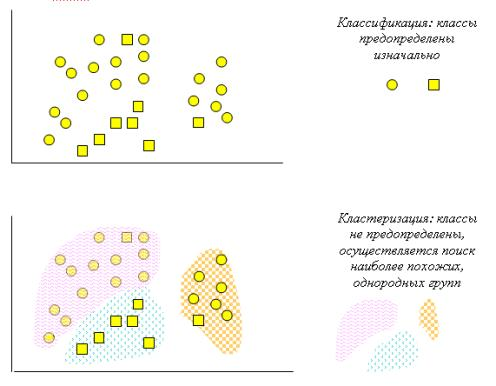)

https://intuit.ru/EDI/21_01_20_1/1579558792-21349/tutorial/25/objects/5/files/5_7.jpg


| Характеристика 	| Классификация 	| Кластеризация 	|
|---	|---	|---	|
| **Контролируемость обучения** 	| Контролируемое обучение	| Неконтролируемое обучение 	|
| **Стратегия** 	| Обучение с учителем 	| Обучение без учителя 	|
| **Наличие метки класса** 	| Обучающее множество сопровождается меткой, указывающей класс, к которому относится наблюдение 	| Метки класса обучающего множества неизвестны 	|
| **Основание для классификации** 	| Новые данные классифицируются на основании обучающего множества 	| Дано множество данных с цель. установления существования классов или кластеров данных 	|

Методы, которые рассмотрим в данном семинаре:


*   K-means
*   DBSCAN
*   Иерархическая кластеризация






## K-means (Метод k-средних)

Данный алгоритм можно схематически представить в виде следующих шагов:

1. Инициализируем центры кластеров случайным образом (должно быть задано количество кластеров).
2. Относим точки к соответствующим кластерам (с минимальным расстоянием до их центра).
3. Производится пересчет центров кластеров по формуле центра масс для всех точек, принадлежащих кластеру.
4. Пункты 2-3 повторяются до тех пор пока центры кластеров перестанут меняться (сильно).

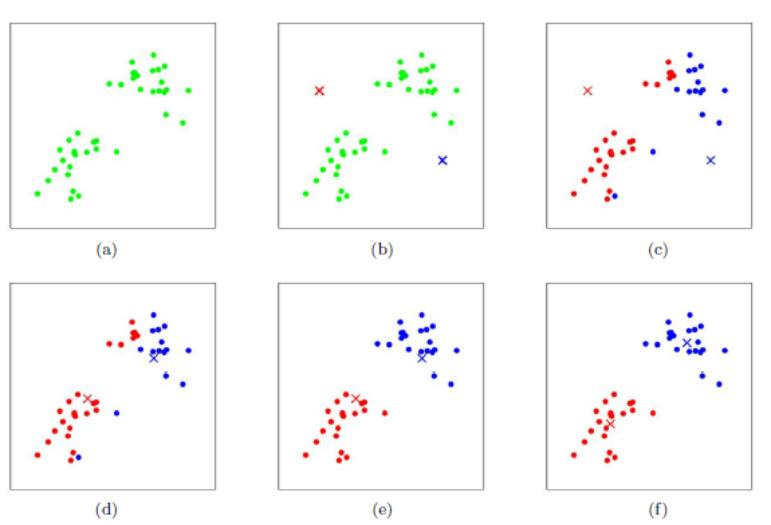

In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

In [2]:
plt.rcParams['figure.figsize'] = [11, 8]

Посмотрим на то, как работает метод.

In [19]:
from sklearn.cluster import KMeans

np.random.seed(123)
X1 = np.random.randn(100,2)
X2 = np.random.randn(100,2) - np.array([10,1])
X3 = np.random.randn(100,2) - np.array([1,10])
X = np.vstack((X1,X2,X3))
y = np.array([1]*100 + [2]*100 + [3]*100)

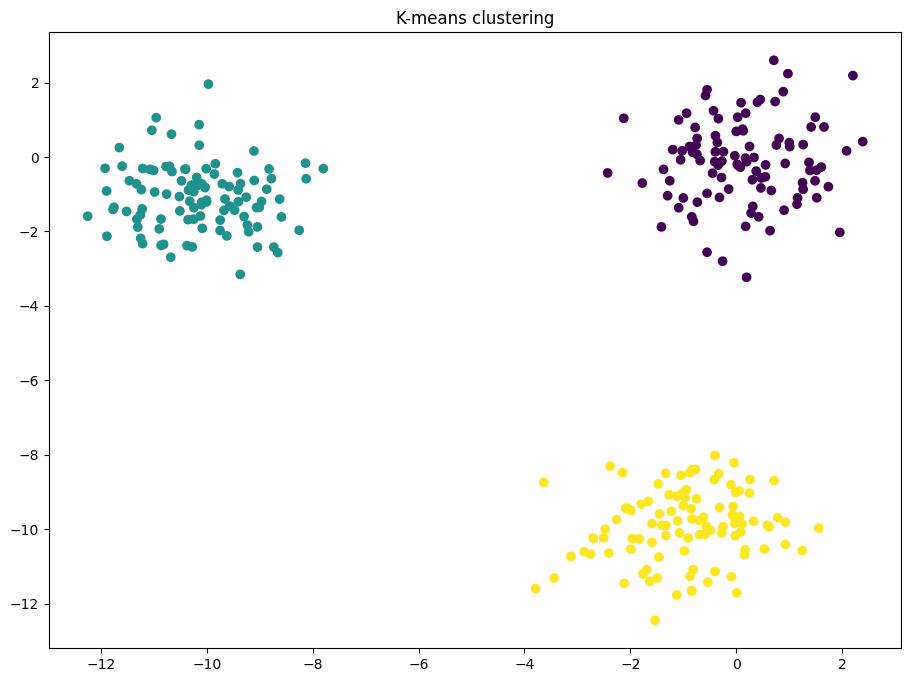

In [20]:
k_means = KMeans(n_clusters = 3)
k_means = k_means.fit(X)
clusters = k_means.predict(X)
plt.scatter(X[:,0], X[:,1], c = clusters)
plt.title('K-means clustering')
plt.show()

Посмотрим, что будет происходить, если мы не угадали с числом кластеров.

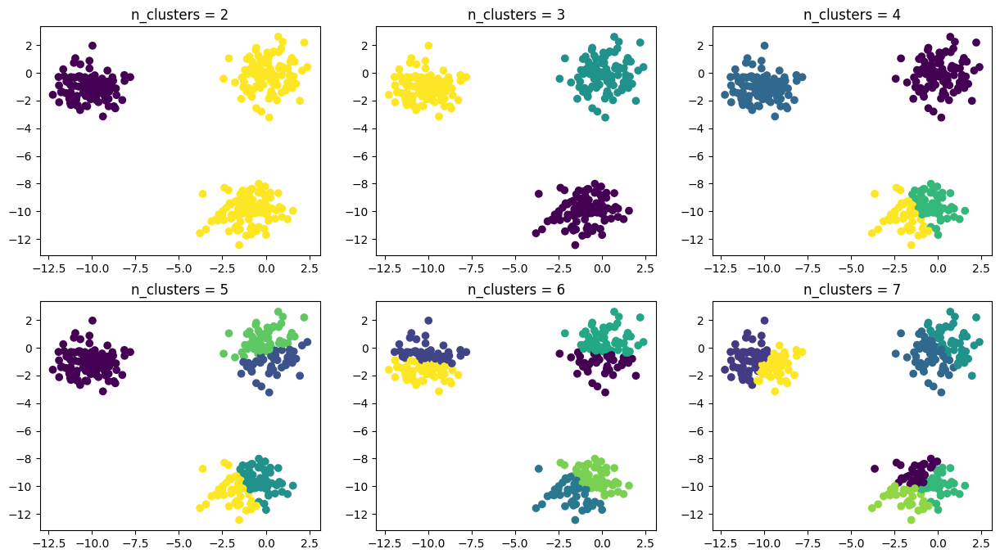

In [21]:
plt.figure(figsize= (15,8))
for n_c in range(2,8):
    k_means = KMeans(n_clusters = n_c)
    k_means = k_means.fit(X)
    clusters = k_means.predict(X)
    plt.subplot(2,3,n_c - 1)
    plt.scatter(X[:,0], X[:,1], c = clusters)
    plt.title('n_clusters = {}'.format(n_c))

plt.show()

Как мы видим, k-means обязательно пытается отдать каждому кластеру какие-то объекты и, как большинство алгоритмов кластеризации, зависит от заданного числа кластеров.

### Параметры K-means

Рассмотрим какие есть параметры у реализации k-means в sklearn

In [23]:
# Создание модели
kmeans = KMeans(
    n_clusters=3,       # Количество кластеров
    init='k-means++',   # Метод инициализации
    n_init=10,          # Количество запусков
    max_iter=300,       # Максимальное число итераций
    tol=1e-4,           # Допуск для сходимости
    random_state=42     # Для воспроизводимости
)

# Обучение модели
kmeans.fit(X)

# Результаты
print("Центроиды:", kmeans.cluster_centers_)
print("Метки кластеров:", kmeans.labels_)
print("Инерция:", kmeans.inertia_)
print("Число итераций:", kmeans.n_iter_)

Центроиды: [[-10.15249366  -1.07622974]
 [ -0.94482255  -9.91902954]
 [  0.130869    -0.12329549]]
Метки кластеров: [2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1]
Инерция: 595.9575971661241
Число итераций: 2


`n_clusters` (по умолчанию 8)
Количество кластеров, которые нужно найти. Это главный параметр, который вы должны задать перед запуском алгоритма.

`init` (по умолчанию k-means++)
Метод инициализации центроидов:

*   'k-means++': Умный выбор начальных центроидов для ускорения сходимости.

*   'random': Случайный выбор начальных центроидов.

`n_init` (по умолчанию 10):
Количество запусков алгоритма с разными начальными центроидами. Из всех запусков выбирается результат с наименьшей инерцией.

`max_iter` (по умолчанию 300):
Максимальное количество итераций для одного запуска алгоритма. Если алгоритм не сошелся за это число итераций, он останавливается.

`tol` (по умолчанию 1e-4):
Допуск для определения сходимости. Если изменение инерции между итерациями меньше этого значения, алгоритм останавливается.

`random_state` (по умолчанию None):
для генератора случайных чисел. Используется для воспроизводимости результатов.

`algorithm` (по умолчанию 'auto'):
Алгоритм, используемый для k-means:
- 'full': Классический EM-алгоритм.
- 'elkan': Оптимизированная версия, которая может быть быстрее для данных с четко разделенными кластерами.
- 'auto': Автоматический выбор между 'full' и 'elkan'.

### **Метод локтя**

Метод локтя используется для выбора оптимального числа кластеров k. Для этого:
*   Запускаем k-means для разных значений k (например, от 1 до 10).
*   Для каждого k вычисляем инерцию.
*   Строим график зависимости инерции от числа кластеров.
*   Ищем "локоть" — точку, после которой инерция перестает значительно уменьшаться.

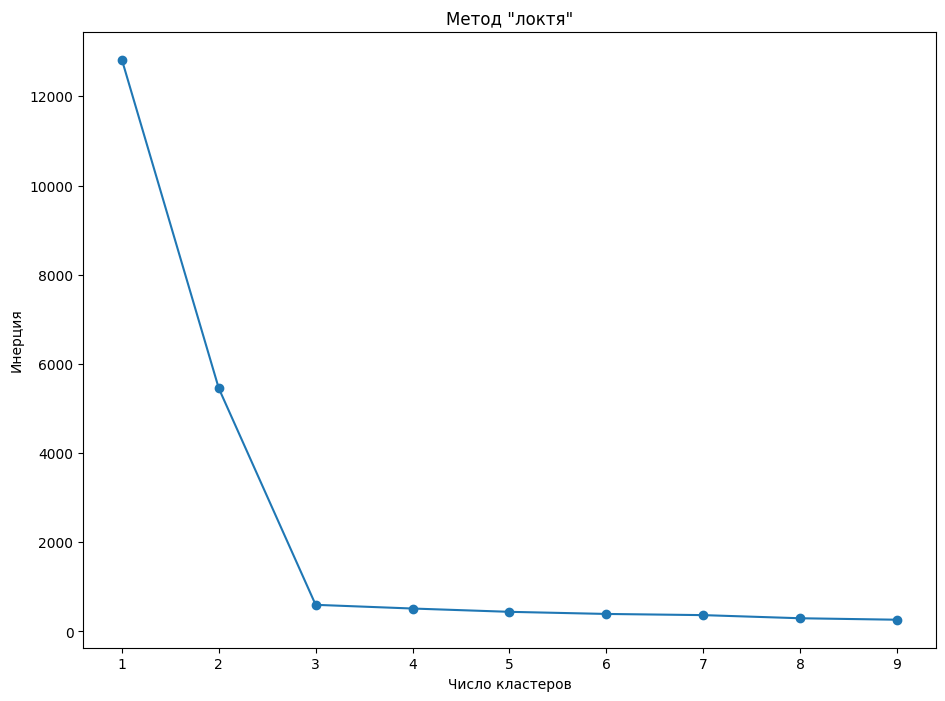

In [6]:
# Метод "локтя" для выбора числа кластеров
inertia = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

# Визуализация метода "локтя"
plt.plot(range(1, 10), inertia, marker='o')
plt.xlabel('Число кластеров')
plt.ylabel('Инерция')
plt.title('Метод "локтя"')
plt.show()

**Inertia (инерция)** в методе k-средних (k-means) — это мера того, насколько плотно точки внутри кластеров сгруппированы вокруг их центроидов. Она вычисляется как сумма квадратов расстояний от каждой точки до центроида её кластера. Чем меньше значение инерции, тем лучше точки сгруппированы вокруг центроидов.

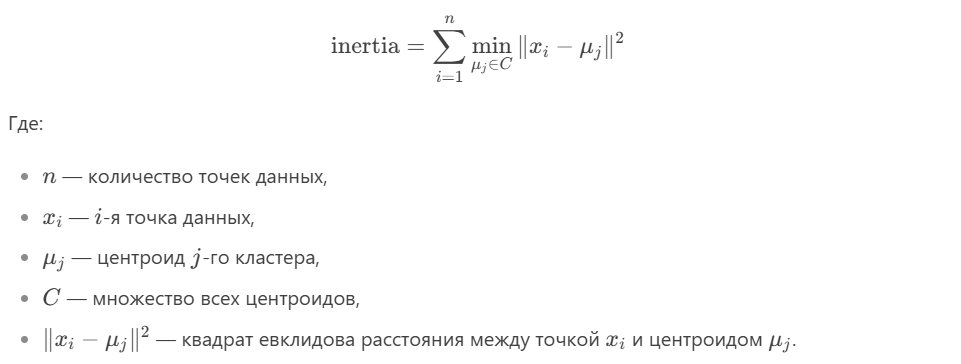

### Silhouette plot

Значение **Silhouette** для каждого наблюдения является мерой того, насколько это наблюдение похоже на наблюдения в собственном кластере по сравнению с наблюдениями в других кластерах. Значение Silhouette находится в диапазоне от -1 до 1.
*   1: Объект идеально соответствует своему кластеру.
*   0: Объект находится на границе между двумя кластерами.
*   -1: Объект, скорее всего, назначен неправильному кластеру.

Высокое значение указывает на то, что наблюдение хорошо соответствует собственному кластеру и плохо соответствует другим кластерам. Если большинство наблюдений имеют низкое или отрицательное значение Silhouette, тогда пользователь должен перестроить кластеризацию с большим или меньшим количеством кластеров.

Среднее значение силуэта: 0.82


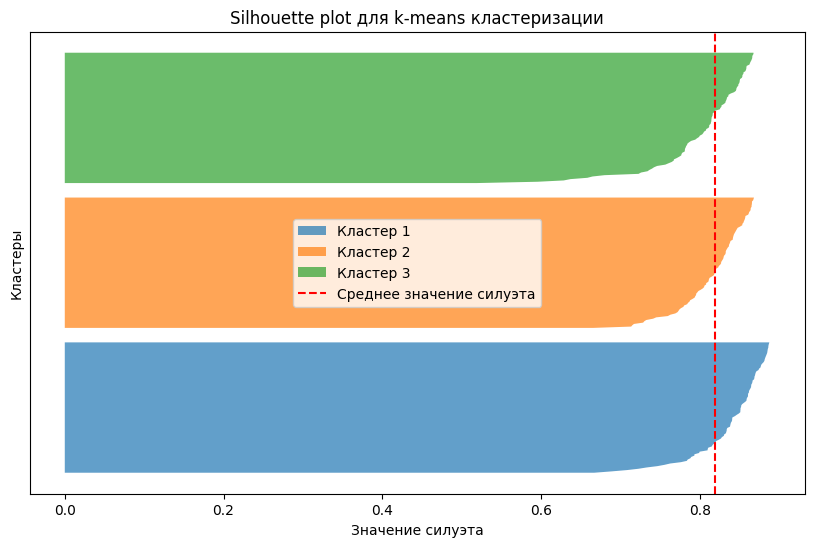

In [11]:
from sklearn.metrics import silhouette_samples, silhouette_score


# Кластеризация с помощью k-means
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X)

# Вычисление значений силуэта для каждого объекта
silhouette_vals = silhouette_samples(X, labels)

# Среднее значение силуэта
silhouette_avg = silhouette_score(X, labels)
print(f"Среднее значение силуэта: {silhouette_avg:.2f}")

# Построение графика силуэта
plt.figure(figsize=(10, 6))
y_lower = 10  # Отступ для визуализации

# Перебираем кластеры
for i in range(3):
    # Собираем значения силуэта для текущего кластера
    cluster_silhouette_vals = silhouette_vals[labels == i]
    cluster_silhouette_vals.sort()

    # Размер текущего кластера
    y_upper = y_lower + cluster_silhouette_vals.shape[0]

    # Закрашиваем область для текущего кластера
    plt.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        cluster_silhouette_vals,
        alpha=0.7,
        label=f"Кластер {i+1}"
    )

    # Обновляем отступ для следующего кластера
    y_lower = y_upper + 10

# Среднее значение силуэта (вертикальная линия)
plt.axvline(x=silhouette_avg, color="red", linestyle="--", label="Среднее значение силуэта")

# Настройка графика
plt.title("Silhouette plot для k-means кластеризации")
plt.xlabel("Значение силуэта")
plt.ylabel("Кластеры")
plt.yticks([])  # Убираем метки на оси Y
plt.legend()
plt.show()

Как интерпретировать Silhouette plot?

**Высота "лепестков":**
Высота каждого "лепестка" соответствует размеру кластера.

**Ширина "лепестков":**
Ширина показывает распределение значений силуэта внутри кластера. Чем шире "лепесток", тем больше разброс значений.

**Среднее значение силуэта** (красная пунктирная линия):
Это среднее значение силуэта для всех объектов. Чем оно ближе к 1, тем лучше кластеризация.

**Отрицательные значения:**
Если есть объекты с отрицательными значениями силуэта, это может указывать на неправильную кластеризацию.

Посмотрим на график при n_clusters=4

Среднее значение силуэта: 0.65


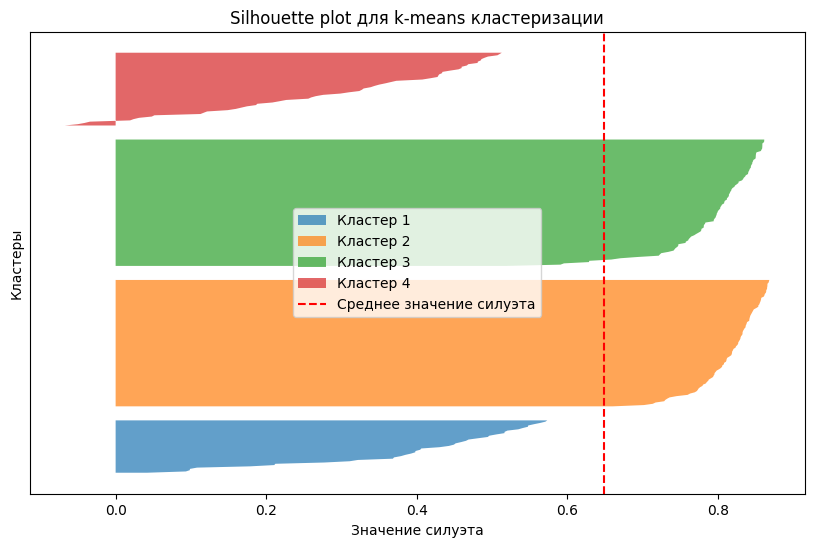

In [12]:
# Кластеризация с помощью k-means
kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(X)

# Вычисление значений силуэта для каждого объекта
silhouette_vals = silhouette_samples(X, labels)

# Среднее значение силуэта
silhouette_avg = silhouette_score(X, labels)
print(f"Среднее значение силуэта: {silhouette_avg:.2f}")

# Построение графика силуэта
plt.figure(figsize=(10, 6))
y_lower = 10  # Отступ для визуализации

# Перебираем кластеры
for i in range(4):
    # Собираем значения силуэта для текущего кластера
    cluster_silhouette_vals = silhouette_vals[labels == i]
    cluster_silhouette_vals.sort()

    # Размер текущего кластера
    y_upper = y_lower + cluster_silhouette_vals.shape[0]

    # Закрашиваем область для текущего кластера
    plt.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        cluster_silhouette_vals,
        alpha=0.7,
        label=f"Кластер {i+1}"
    )

    # Обновляем отступ для следующего кластера
    y_lower = y_upper + 10

# Среднее значение силуэта (вертикальная линия)
plt.axvline(x=silhouette_avg, color="red", linestyle="--", label="Среднее значение силуэта")

# Настройка графика
plt.title("Silhouette plot для k-means кластеризации")
plt.xlabel("Значение силуэта")
plt.ylabel("Кластеры")
plt.yticks([])  # Убираем метки на оси Y
plt.legend()
plt.show()

Посмотрим на график при n_clusters=2

Среднее значение силуэта: 0.58


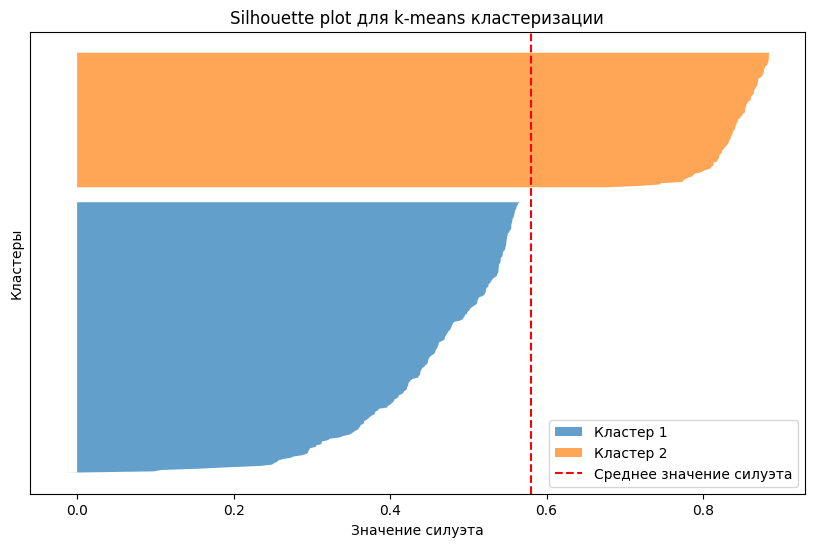

In [13]:
# Кластеризация с помощью k-means
kmeans = KMeans(n_clusters=2, random_state=42)
labels = kmeans.fit_predict(X)

# Вычисление значений силуэта для каждого объекта
silhouette_vals = silhouette_samples(X, labels)

# Среднее значение силуэта
silhouette_avg = silhouette_score(X, labels)
print(f"Среднее значение силуэта: {silhouette_avg:.2f}")

# Построение графика силуэта
plt.figure(figsize=(10, 6))
y_lower = 10  # Отступ для визуализации

# Перебираем кластеры
for i in range(2):
    # Собираем значения силуэта для текущего кластера
    cluster_silhouette_vals = silhouette_vals[labels == i]
    cluster_silhouette_vals.sort()

    # Размер текущего кластера
    y_upper = y_lower + cluster_silhouette_vals.shape[0]

    # Закрашиваем область для текущего кластера
    plt.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        cluster_silhouette_vals,
        alpha=0.7,
        label=f"Кластер {i+1}"
    )

    # Обновляем отступ для следующего кластера
    y_lower = y_upper + 10

# Среднее значение силуэта (вертикальная линия)
plt.axvline(x=silhouette_avg, color="red", linestyle="--", label="Среднее значение силуэта")

# Настройка графика
plt.title("Silhouette plot для k-means кластеризации")
plt.xlabel("Значение силуэта")
plt.ylabel("Кластеры")
plt.yticks([])  # Убираем метки на оси Y
plt.legend()
plt.show()

### Индекс Дэвиса-Боулдина

**Индекс Дэвиса-Боулдина (Davies-Bouldin Index, DBI)** — это метрика для оценки качества кластеризации. Чем меньше значение индекса, тем лучше кластеризация. Он учитывает компактность кластеров (насколько близки точки внутри кластера) и разделение кластеров (насколько далеко кластеры друг от друга).

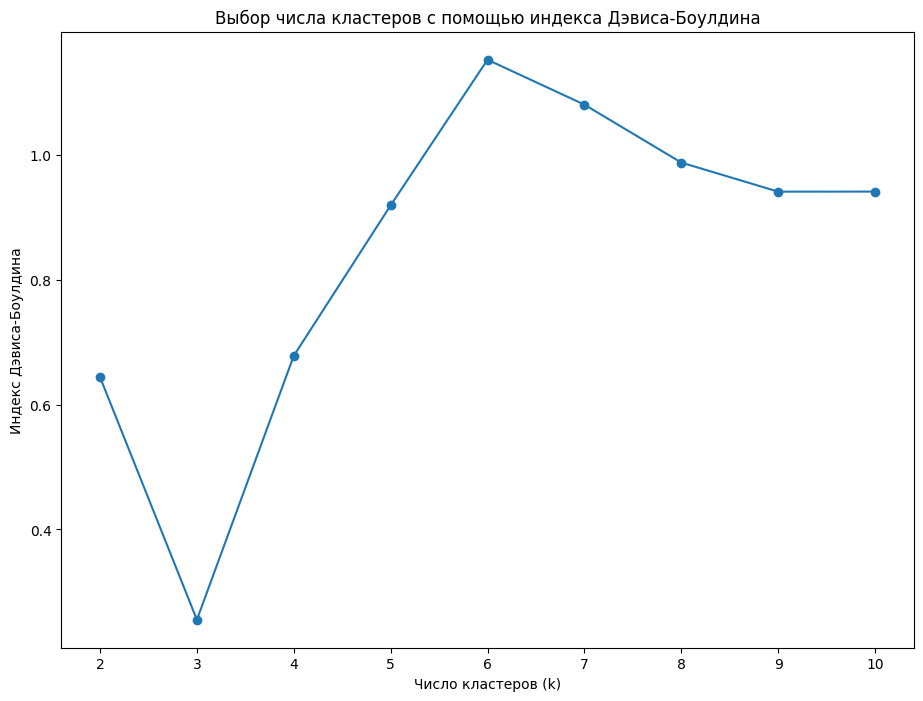

In [15]:
from sklearn.metrics import davies_bouldin_score

dbi_scores = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    dbi = davies_bouldin_score(X, labels)
    dbi_scores.append(dbi)

plt.plot(k_values, dbi_scores, marker='o')
plt.xlabel('Число кластеров (k)')
plt.ylabel('Индекс Дэвиса-Боулдина')
plt.title('Выбор числа кластеров с помощью индекса Дэвиса-Боулдина')
plt.show()

### Вариация k-medians

Также есть вариация **k-medians**, которая вместо центров кластеров вычисляет "центроиды", то есть при вычислении центров кластеров использует медиану вместо среднего. Это позволяет алгоритму стать более устойчивым к выбросам.

(пример реализации алгоритма pyclustering по [ссылке](https://www.kaggle.com/code/rafaelsaraivacampos/k-medians-clustering) )

[Визуализация работы K-Means](https://www.naftaliharris.com/blog/visualizing-k-means-clustering/)

## DBSCAN

**(Density-based spatial clustering of applications with noise)**

Это алгоритм, основанный на плотности — если дан набор объектов в некотором пространстве, алгоритм группирует вместе объекты, которые расположены близко и помечает как выбросы объекты, которые находятся в областях с малой плотностью (ближайшие соседи которых лежат далеко).

В отличие от k-means, он не требует задания числа кластеров заранее и может находить кластеры произвольной формы. Кроме того, DBSCAN способен идентифицировать выбросы (шум).

Алгоритм имеет два основных гиперпараметра:
1. `eps` &mdash; радиус рассматриваемой окрестности для поиска соседей
2. `min_samples` &mdash; число соседей в окрестности (Минимальное количество точек в окрестности радиуса eps, чтобы точка считалась основной (core))

Для выполнения кластеризации DBSCAN точки делятся на основные точки, достижимые по плотности точки и выпадающие следующим образом:

- Точка $p$ является основной точкой (**core point**), если по меньшей мере `min_samples` точек находятся на расстоянии, не превосходящем
`eps` от неё. Говорят, что эти точки достижимы прямо из $p$.

-  Точка $q$ прямо достижима из $p$, если точка $q$ находится на расстоянии, не большем `eps`, от точки $p$, и $p$ — основная точка.
Точка $q$ достижима из $p$, если имеется путь
$p_1,…,p_n$ где $p_1=p$ и $p_n=q$ , а каждая точка $p_{i+1}$ достижима прямо из $p_i$ (все точки на пути должны быть основными, за исключением $q$).  Т.е. Точка, у которой в окрестности радиуса `eps` меньше `min_samples` соседей, но она находится в окрестности ядерной точки. Также называется **Граничная точка**.

Все точки, не достижимые из основных точек, считаются выбросами (**Noise point**).

Теперь, если $p$ является основной точкой, то она формирует кластер вместе со всеми точками (основными или неосновными), достижимыми из этой точки. Каждый кластер содержит по меньшей мере одну основную точку. Неосновные точки могут быть частью кластера, но они формируют его «край», поскольку не могут быть использованы для достижения других точек.



Рассмотрим диаграмму, параметр `min_samples`=4.

Точка $A$ и другие красные точки являются основными точками, поскольку область с радиусом
`eps` , окружающая эти точки, содержит по меньшей мере 4 точки (включая саму точку). Поскольку все они достижимы друг из друга, точки образуют один кластер. Точки $B$ и $C$ основными не являются, но достижимы из $A$ (через другие основные точки), и также принадлежат кластеру. Точка $N$ является точкой шума, она не является ни основной точкой, ни доступной прямо.

<p><a href="https://commons.wikimedia.org/wiki/File:DBSCAN-Illustration.svg#/media/Файл:DBSCAN-Illustration.svg"><img src="https://upload.wikimedia.org/wikipedia/commons/thumb/a/af/DBSCAN-Illustration.svg/1200px-DBSCAN-Illustration.svg.png" alt="DBSCAN-Illustration.svg" width="450" height="450"> </a><br>Автор: <a href="//commons.wikimedia.org/wiki/User:Chire" title="User:Chire">Chire</a> &mdash; <span class="int-own-work" lang="ru">собственная работа</span>, <a href="https://creativecommons.org/licenses/by-sa/3.0" title="Creative Commons Attribution-Share Alike 3.0">CC BY-SA 3.0</a>

### Алгоритм DBSCAN:

**1. Инициализация:**

*  Все точки помечаются как непосещенные.

*  Создается пустой список кластеров.

**2. Поиск кластеров:**

*  Для каждой непосещенной точки:

    + Если точка является ядерной (имеет не менее min_samples соседей в радиусе eps):

        - Создается новый кластер.

        - Все достижимые точки (прямо или косвенно) добавляются в этот кластер.

    + Если точка не является ядерной, она помечается как шумовая.

**3. Завершение:**

*  Когда все точки обработаны, алгоритм возвращает кластеры и шумовые точки.

### Параметры DBSCAN
`eps`
Радиус окрестности для поиска соседей.
* Слишком маленькое значение: Большинство точек будут шумовыми.
* Слишком большое значение: Все точки могут объединиться в один кластер.


`min_samples`
Минимальное количество точек в окрестности радиуса eps, чтобы точка считалась ядерной.
* Чем больше значение, тем более "плотные" кластеры будут найдены.


`metric`
Метрика расстояния (по умолчанию 'euclidean').
* Другие варианты: 'manhattan', 'cosine' и т.д.


`algorithm`
Алгоритм для поиска соседей (по умолчанию 'auto').
* Другие варианты: 'ball_tree', 'kd_tree', 'brute'.

Посмотрим на результаты кластеризации при разном выборе параметров `eps` и `min_samples`.

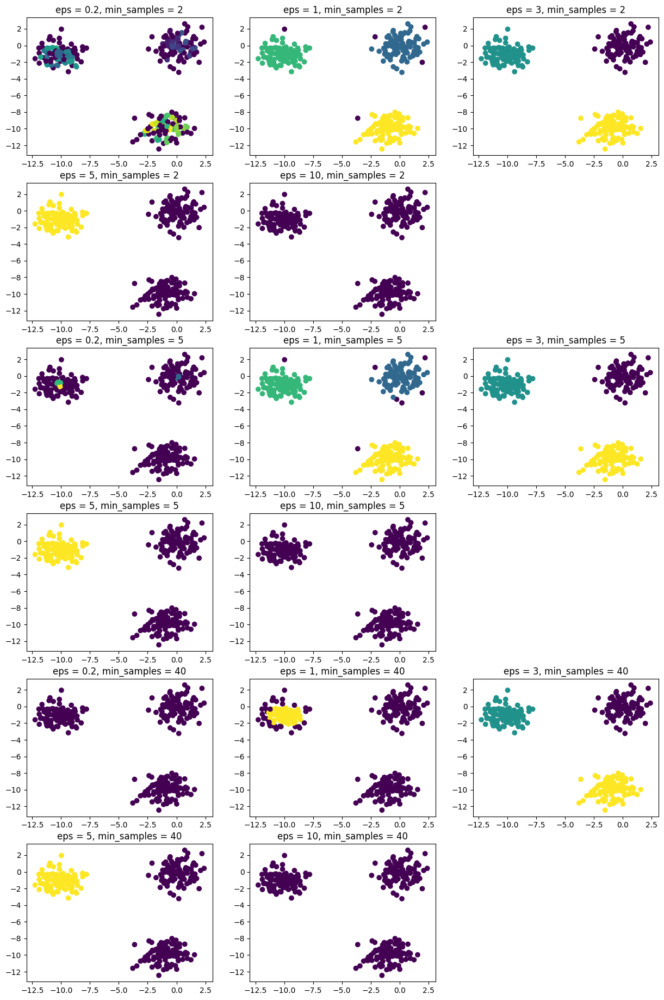

In [28]:
from sklearn.cluster import DBSCAN
plt.figure(figsize= (15,23))
i = 1
for samples in [2, 5, 40]:
    for e in [0.2, 1, 3, 5, 10]:
        dbscan = DBSCAN(eps=e, min_samples=samples)
        clusters = dbscan.fit_predict(X)
        plt.subplot(6, 3, i)
        plt.scatter(X[:,0], X[:,1], c = clusters)
        plt.title('eps = {}, min_samples = {}'.format(e, samples))
        i += 1
    i+=1

plt.show()

[Визуализация работы DBSCAN](https://www.naftaliharris.com/blog/visualizing-dbscan-clustering/)
(Стоит посмотреть)

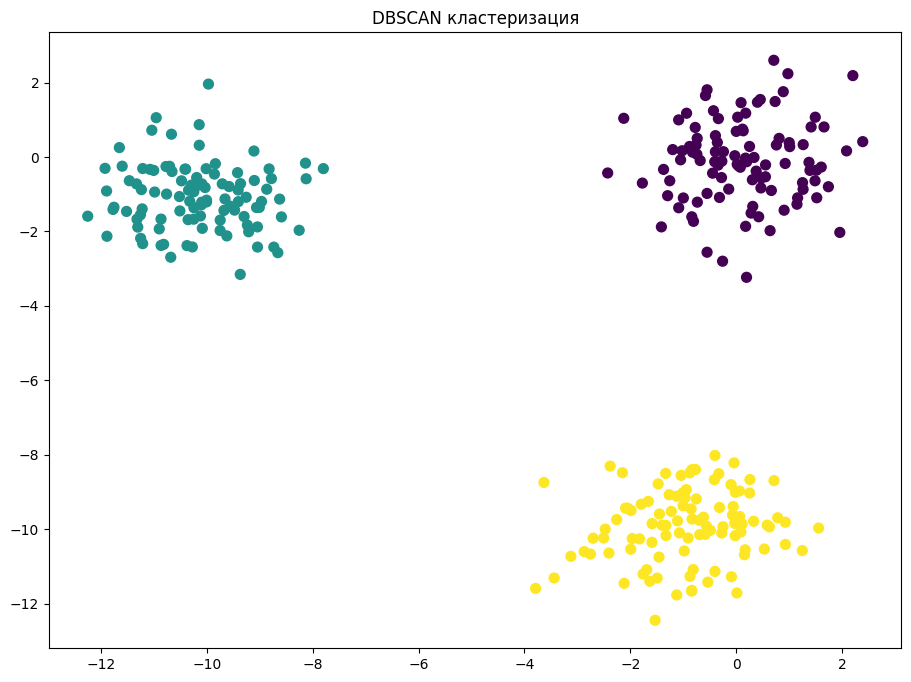

In [40]:
# Применение DBSCAN
dbscan = DBSCAN(eps=3, min_samples=2)
labels = dbscan.fit_predict(X)

# Визуализация результатов
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis')
plt.title("DBSCAN кластеризация")
plt.show()

### Silhouette Plot

Силуэт: 0.82


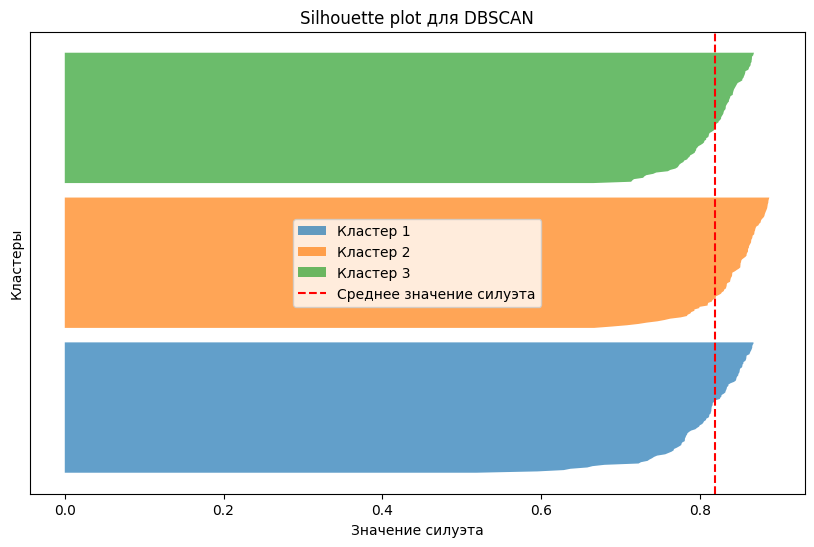

In [41]:
# Вычисляем значения силуэта для каждого объекта
silhouette_vals = silhouette_samples(X, labels)

# Визуализация
plt.figure(figsize=(10, 6))
y_lower = 10

silhouette_avg = silhouette_score(X, labels)
print(f"Силуэт: {silhouette_avg:.2f}")

for i in range(len(set(labels))):
    cluster_silhouette_vals = silhouette_vals[labels == i]
    cluster_silhouette_vals.sort()
    y_upper = y_lower + cluster_silhouette_vals.shape[0]
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_silhouette_vals, alpha=0.7, label=f"Кластер {i+1}")
    y_lower = y_upper + 10

plt.axvline(x=silhouette_avg, color="red", linestyle="--", label="Среднее значение силуэта")
plt.title("Silhouette plot для DBSCAN")
plt.xlabel("Значение силуэта")
plt.ylabel("Кластеры")
plt.yticks([])
plt.legend()
plt.show()

### Индекс Дэвиса-Боулдина

In [42]:
from sklearn.metrics import davies_bouldin_score

dbi = davies_bouldin_score(X, labels)
print(f"Индекс Дэвиса-Боулдина: {dbi:.2f}")

Индекс Дэвиса-Боулдина: 0.26


### Плюсы и минусы DBSCAN

+
* Не требует задания числа кластеров.
* Может находить кластеры произвольной формы.
* Устойчив к шуму (выбросам).

-
* Чувствителен к выбору параметров eps и min_samples.
* Плохо работает с кластерами разной плотности.
* Требует больше вычислительных ресурсов для больших данных.

## Сравнение k-means и DBSCAN




Результаты работы методов на других датасетах:

In [ ]:
from sklearn.datasets import make_moons, make_circles

In [ ]:
X, y = make_moons(n_samples=500, noise=0.1)

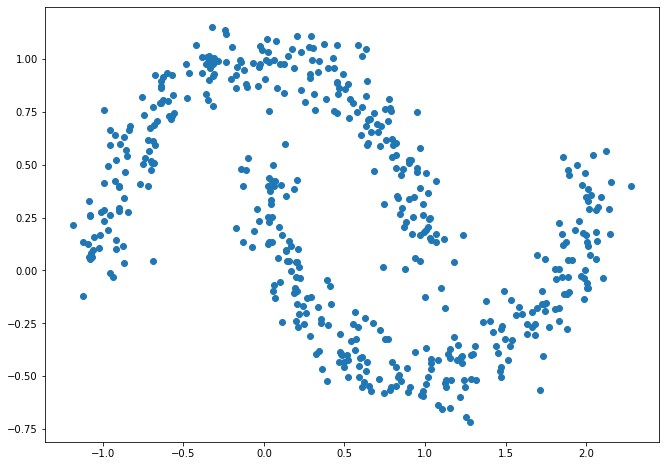

In [ ]:
plt.scatter(X[:,0], X[:,1])
plt.show()

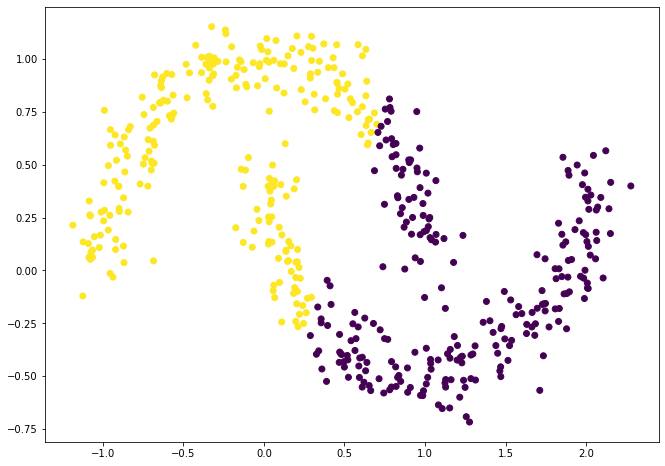

In [ ]:
k_means = KMeans(n_clusters = 2)
k_means = k_means.fit(X)
clusters = k_means.predict(X)
plt.scatter(X[:,0], X[:,1], c=clusters)
plt.show()

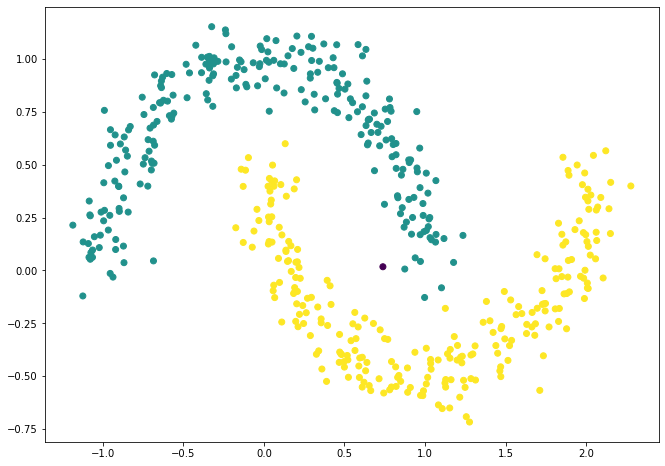

In [ ]:
dbscan = DBSCAN(eps=0.2, min_samples=10)
clusters = dbscan.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=clusters)
plt.show()

Как вы думаете, почему так выходит? (Пояснения ниже)

In [ ]:
X, y = make_circles(n_samples=500, noise=0.05, factor=0.5)

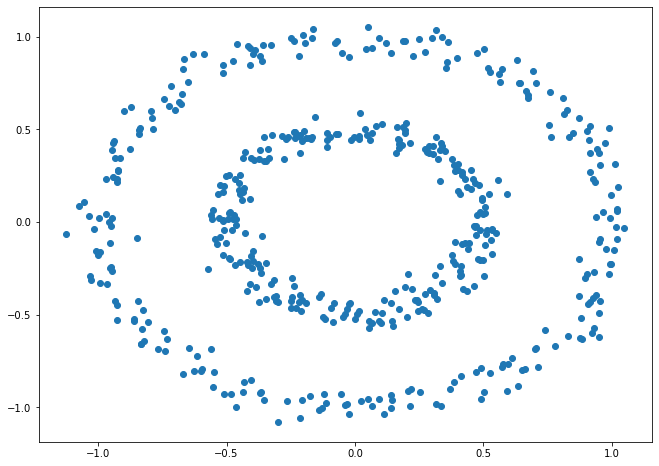

In [ ]:
plt.scatter(X[:,0], X[:,1])
plt.show()

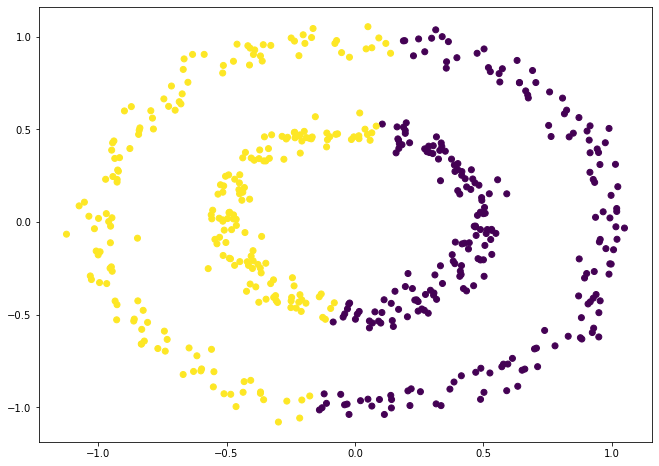

In [ ]:
k_means = KMeans(n_clusters = 2)
k_means = k_means.fit(X)
clusters = k_means.predict(X)
plt.scatter(X[:,0], X[:,1], c=clusters)
plt.show()

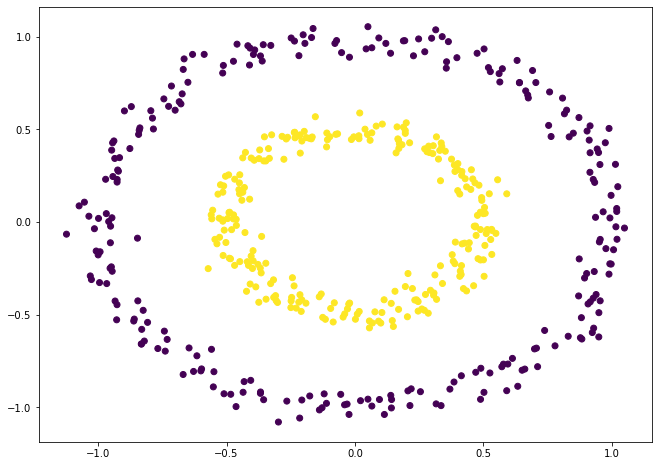

In [ ]:
dbscan = DBSCAN(eps=0.2, min_samples=10)
clusters = dbscan.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=clusters)
plt.show()

k-Means выделяет только выпуклые кластеры, сходного размера. Не очень хорошо работает с шумными данными. Хуже видит аномалии. С другой стороны, k-means лучше справляется с большими данными и размерностью, а также разреженными данными с переменной плотностью (DBSCAN скорее относит разные плотности к разным кластерам).

## Иерархическая кластеризация

Другим вариантом к построению кластеров является иерархический подход, в котором алгоритм жадным образом строит кластеры. Существует два варианта иерархической кластеризации:

1. аггломеративная, в которой алгоритм на каждой итерации объединяет два меньших кластера в один
2. дивизивная, в которой алгоритм на каждой итерации разбивает один кластер на два более мелких

Мы рассмотрим аггломеративный подход к кластеризации (дивизивный можно рассмотреть по аналогии).

Опишем схематически алгоритм аггломеративной иерархической кластеризации:

- Инициализируем наше множество кластеров, каждая точка считается своим кластером. То есть для выборки размера $N$ у нас на первой итерации будет $N$ кластеров. Также в качестве входного параметра алгоритму подается метрика расстояния между двумя кластерами. Одной из популярных метрик является расстояние Уорда.

- На каждой итерации  мы объединяем два кластера в один. Объединяющиеся кластера выбираются в соответствии с наименьшим расстоянием Уорда. То есть в соответствии с выбранным нами расстоянием эти два кластера будут наиболее похожи и поэтому объединяются.

- Предыдущий шаг повторяется вплоть до объединения всех точек один кластер.

Расстояние Уорда — между кластерами берётся прирост суммы квадратов расстояний объектов до центра кластера, получаемого в результате их объединения.

$$
\Delta = \sum_i{(x_i-\bar{x})^2} - \sum_{x_i \in A}(x_i - \bar{a})^2 - \sum_{x_i \in B}(x_i - \bar{b})^2
$$

В результате в данном подходе мы можем выбрать любое количество кластеров после завершения процедуры, просто остановив алгоритм на нужном нам шаге. К тому же данный алгоритм гораздо менее чувствителен к выбору метрики между точками, тогда как другие алгоритмы сильно зависят от этого.

Для визуализации иерархической кластеризации удобно строить дендрограммы, в которых разница между уровнями равна выбранному расстоянию объединяющихся на данном этапе кластеров.

Посмотрим на иерархическую кластеризацию на примере:


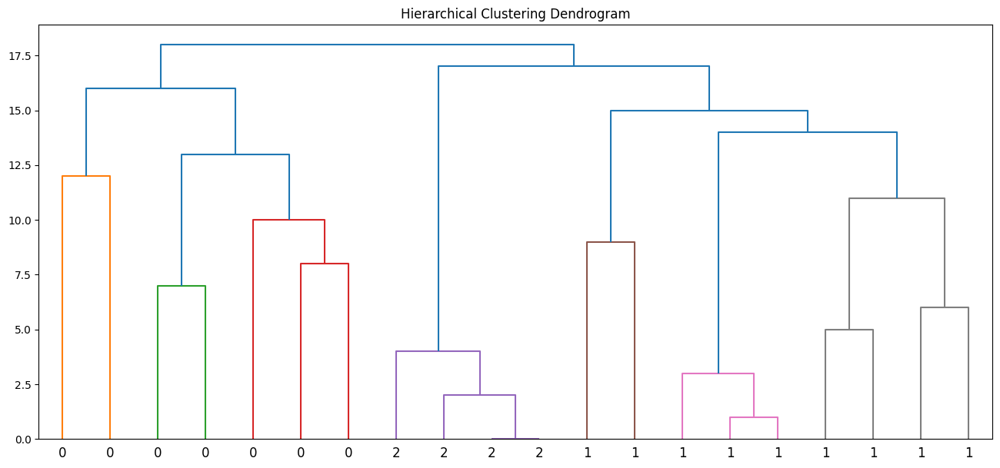

In [46]:
from scipy.cluster.hierarchy import dendrogram
from sklearn.datasets import load_iris
from sklearn.cluster import AgglomerativeClustering

def plot_dendrogram(model, **kwargs):

    # Children of hierarchical clustering
    children = model.children_

    # Distances between each pair of children
    # Since we don't have this information, we can use a uniform one for plotting
    distance = np.arange(children.shape[0])

    # The number of observations contained in each cluster level
    no_of_observations = np.arange(2, children.shape[0]+2)

    # Create linkage matrix and then plot the dendrogram
    # linkage matrix format: https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.linkage.html#scipy.cluster.hierarchy.linkage
    linkage_matrix = np.column_stack([children, distance, no_of_observations]).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)


iris = load_iris()
X = iris.data[:20]
model = AgglomerativeClustering(n_clusters=3)

model = model.fit(X)
plt.figure(figsize=(16,7))
plot_dendrogram(model, labels=model.labels_)
plt.title('Hierarchical Clustering Dendrogram')
plt.show()

Если нет каких-то специализированных условий (например, известно, что кластеров должно быть не более $K$), то число кластеров можно выбирать по резкому скачку дендрограммы. Кроме того, в некоторых задачах важно понимать, для чего делается кластеризация и доменную область задачи — исходя из этого можно сильно сократить искомое количество кластеров.

Также в иерархическую кластеризацию можно передавать дополнительную информацию вида *I-я и J-я точки "похожи"*. Это задается через матрицу связей (**kneighbors_graph**).

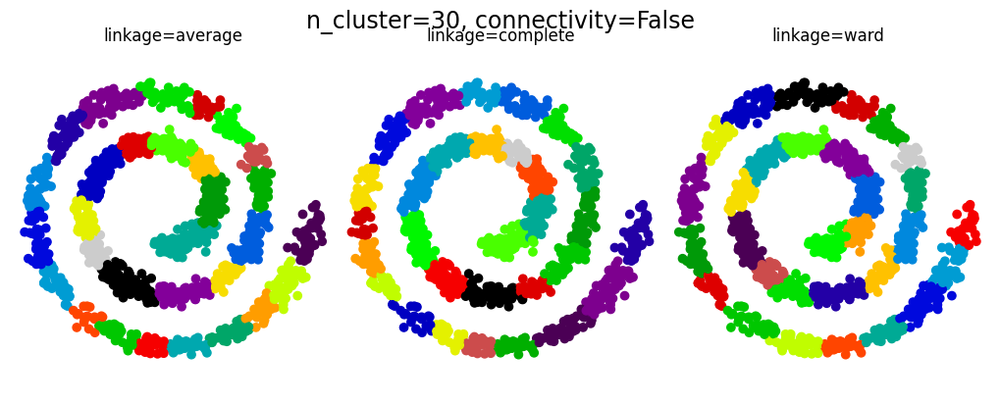

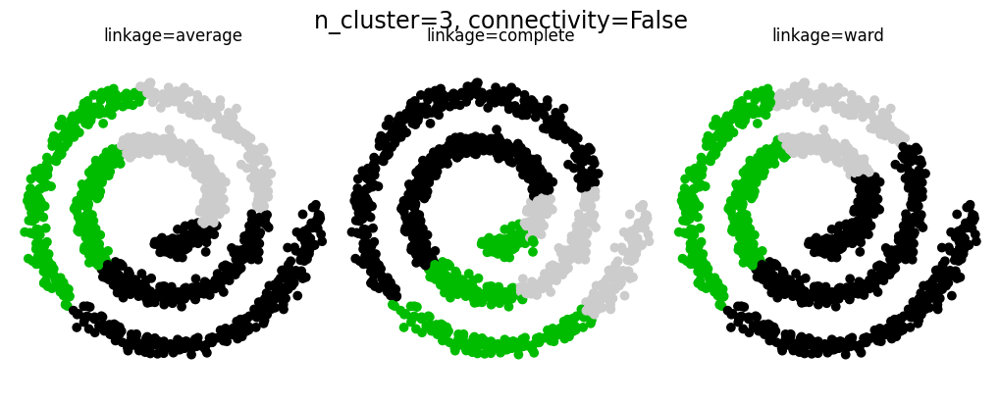

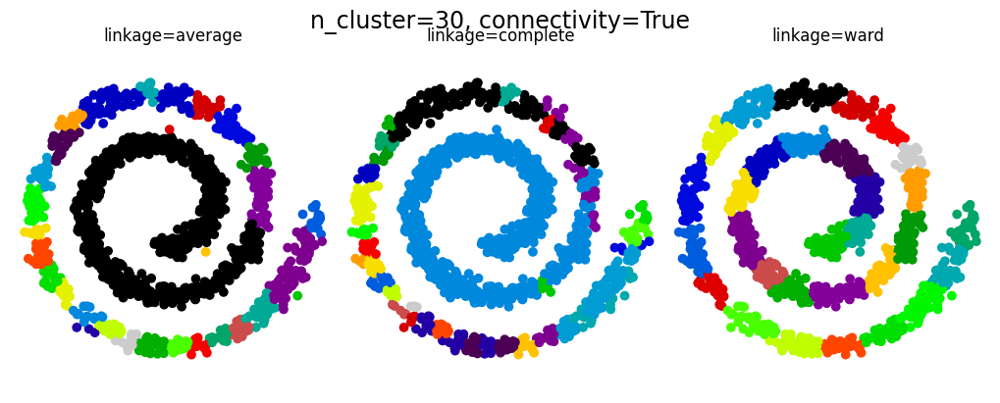

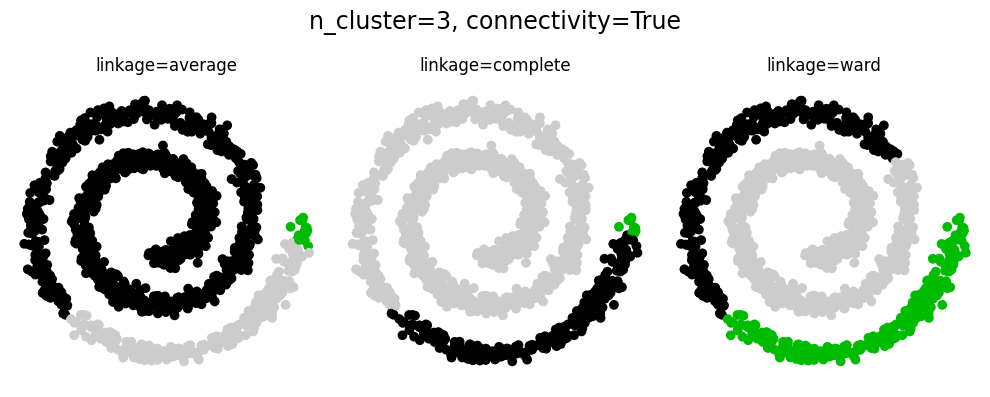

In [47]:
import time
import matplotlib.pyplot as plt
import numpy as np

from sklearn.cluster import AgglomerativeClustering
from sklearn.neighbors import kneighbors_graph

# Generate sample data
n_samples = 1500
np.random.seed(0)
t = 1.5 * np.pi * (1 + 3 * np.random.rand(1, n_samples))
x = t * np.cos(t)
y = t * np.sin(t)


X = np.concatenate((x, y))
X += .7 * np.random.randn(2, n_samples)
X = X.T

# Create a graph capturing local connectivity. Larger number of neighbors
# will give more homogeneous clusters to the cost of computation
# time. A very large number of neighbors gives more evenly distributed
# cluster sizes, but may not impose the local manifold structure of
# the data
knn_graph = kneighbors_graph(X, 30, include_self=False)

for connectivity in (None, knn_graph):
    for n_clusters in (30, 3):
        plt.figure(figsize=(10, 4))
        for index, linkage in enumerate(('average',
                                         'complete',
                                         'ward')):
            plt.subplot(1, 3, index + 1)
            model = AgglomerativeClustering(linkage=linkage,
                                            connectivity=connectivity,
                                            n_clusters=n_clusters)
            model.fit(X)
            plt.scatter(X[:, 0], X[:, 1], c=model.labels_,
                        cmap=plt.cm.nipy_spectral)
            plt.title('linkage=%s' % linkage,
                      fontdict=dict(verticalalignment='top'))
            plt.axis('equal')
            plt.axis('off')

            plt.subplots_adjust(bottom=0, top=.89, wspace=0,
                                left=0, right=1)
            plt.suptitle('n_cluster=%i, connectivity=%r' %
                         (n_clusters, connectivity is not None), size=17)

plt.tight_layout()
plt.show()

Параметр **linkage** задает метрику, используемую для объединения кластеров. Предусмотрены следующие метрики близости кластеров:


*   Ward – минимизирует сумму квадратов разностей во всех кластерах
*   Average – минимизирует среднее расстояние между всеми наблюдениями пар кластеров.
*   Maximum (complete) – сводит к минимуму максимальное расстояние между наблюдениями пар кластеров
*   Minimum (single)– минимизирует расстояние между ближайшими наблюдениями пар кластеров










### Параметры

`n_clusters` (по умолчанию 2):
Количество кластеров, которые нужно найти.

`metric` (по умолчанию 'euclidean'):
Метрика расстояния между точками. Возможные значения:

* 'euclidean': Евклидово расстояние.
* 'manhattan': Манхэттенское расстояние.
* 'cosine': Косинусное расстояние.

Также можно передать свою функцию для вычисления расстояния.

`linkage` (по умолчанию 'ward'):
* 'ward': Метод Уорда (минимизирует дисперсию). Работает только с евклидовым расстоянием.
* 'complete': Полная связь (максимальное расстояние между точками кластеров).
* 'average': Средняя связь (среднее расстояние между точками кластеров).
* 'single': Одиночная связь (минимальное расстояние между точками кластеров).

`compute_full_tree` (по умолчанию 'auto'):
Если True, строится полное дерево кластеров (даже если `n_clusters` задано). Если 'auto', полное дерево строится только если `n_clusters` не задано.

`distance_threshold` (по умолчанию None):
Пороговое значение расстояния для объединения кластеров. Если расстояние между кластерами превышает это значение, объединение прекращается. Если задано, то `n_clusters` должно быть None.

`compute_distances` (по умолчанию False):
Если True, вычисляются расстояния между объединяемыми кластерами. Это может быть полезно для анализа дендрограммы.

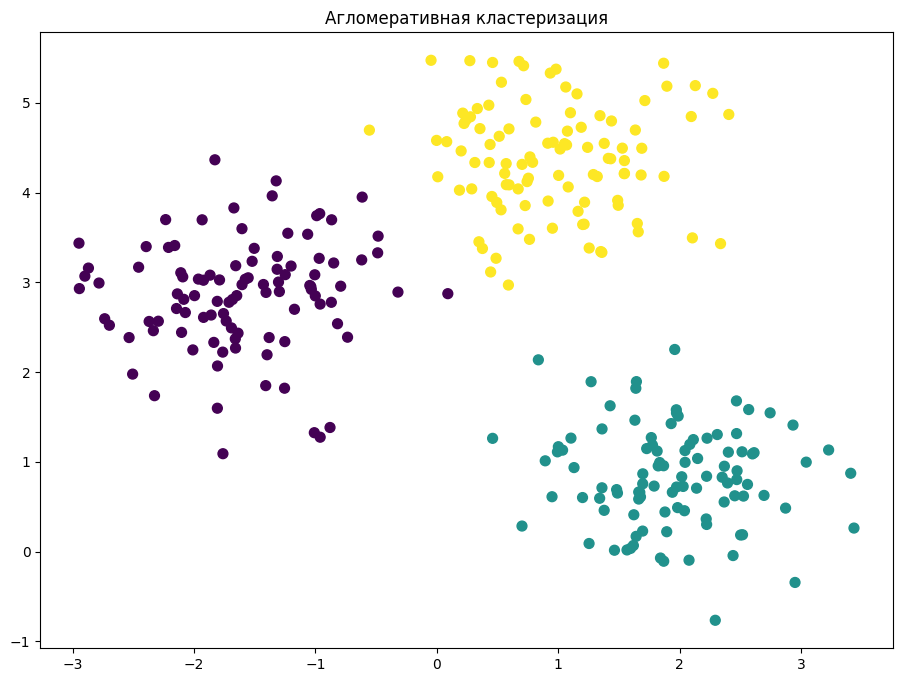

In [55]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

X, _ = make_blobs(n_samples=300, centers=3, cluster_std=0.60, random_state=0)

agglo = AgglomerativeClustering(
    n_clusters=3,              # Количество кластеров
    metric='euclidean',      # Метрика расстояния
    linkage='ward',            # Метод объединения
    compute_full_tree='auto',  # Строить полное дерево
    distance_threshold=None,   # Порог расстояния
    compute_distances=False    # Вычислять расстояния
)

labels = agglo.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis')
plt.title("Агломеративная кластеризация")
plt.show()

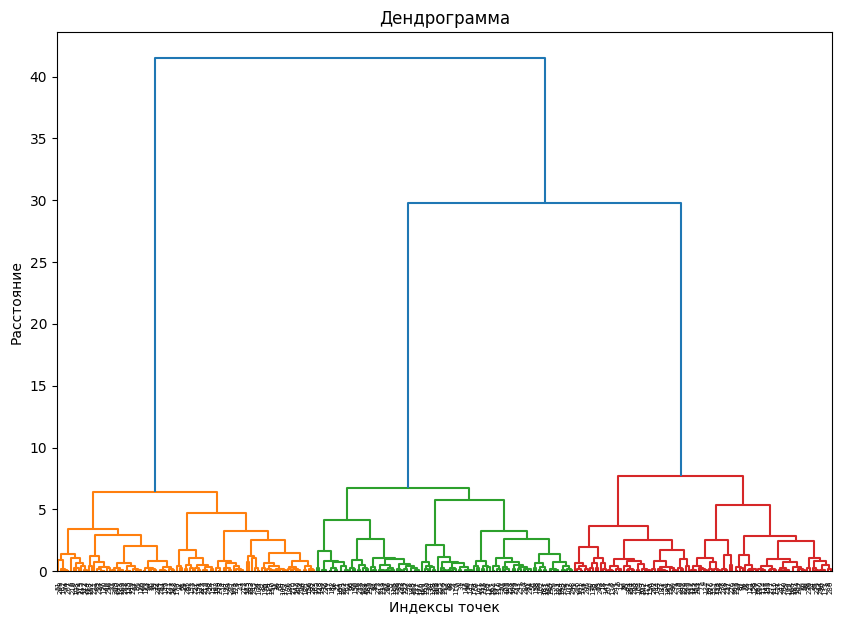

In [56]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Вычисляем linkage matrix
Z = linkage(X, method='ward')

# Построение дендрограммы
plt.figure(figsize=(10, 7))
dendrogram(Z)
plt.title("Дендрограмма")
plt.xlabel("Индексы точек")
plt.ylabel("Расстояние")
plt.show()

### Плюсы и минусы

Плюсы
* Не требует задания числа кластеров заранее (можно выбрать по дендрограмме).
* Может находить кластеры произвольной формы (в зависимости от метода объединения).
* Дендрограмма помогает интерпретировать результаты.

Минусы

* Подойдет для набора данных с небольшим количеством наблюдений
* Чувствительность к шуму и выбросам



## Сравнение работы алгоритмов

Сгенерируем кластеры разной формы и посмотрим на результаты работы алгоритмов

Automatically created module for IPython interactive environment


C:\Users\User\AppData\Local\Temp\ipykernel_11848\177255447.py:112: DeprecationWarning:

`np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations

C:\Users\User\AppData\Local\Temp\ipykernel_11848\177255447.py:112: DeprecationWarning:

`np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
D

C:\Users\User\AppData\Local\Temp\ipykernel_11848\177255447.py:112: DeprecationWarning:

`np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations

C:\Users\User\AppData\Local\Temp\ipykernel_11848\177255447.py:112: DeprecationWarning:

`np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
D

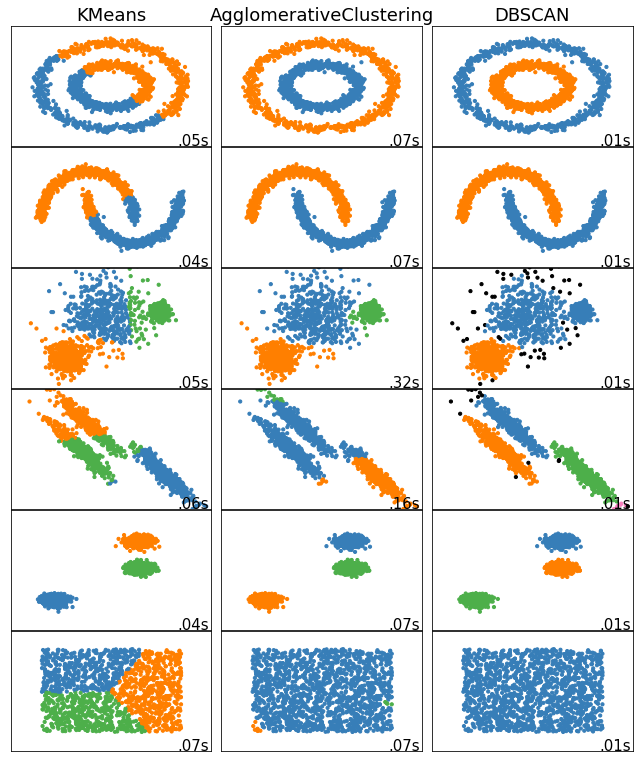

In [ ]:
print(__doc__)

import time
import warnings

import numpy as np
import matplotlib.pyplot as plt

from sklearn import cluster, datasets, mixture
from sklearn.neighbors import kneighbors_graph
from sklearn.preprocessing import StandardScaler
from itertools import cycle, islice

np.random.seed(0)

# ============
# Generate datasets. We choose the size big enough to see the scalability
# of the algorithms, but not too big to avoid too long running times
# ============
n_samples = 1500
noisy_circles = datasets.make_circles(n_samples=n_samples, factor=.5,
                                      noise=.05)
noisy_moons = datasets.make_moons(n_samples=n_samples, noise=.05)
blobs = datasets.make_blobs(n_samples=n_samples, random_state=8)
no_structure = np.random.rand(n_samples, 2), None

# Anisotropicly distributed data
random_state = 170
X, y = datasets.make_blobs(n_samples=n_samples, random_state=random_state)
transformation = [[0.6, -0.6], [-0.4, 0.8]]
X_aniso = np.dot(X, transformation)
aniso = (X_aniso, y)

# blobs with varied variances
varied = datasets.make_blobs(n_samples=n_samples,
                             cluster_std=[1.0, 2.5, 0.5],
                             random_state=random_state)

# ============
# Set up cluster parameters
# ============
plt.figure(figsize=(3 * 2 + 3, 10.5))
plt.subplots_adjust(left=.02, right=.98, bottom=.001, top=.96, wspace=.05,
                    hspace=.01)

plot_num = 1

default_base = {'quantile': .3,
                'eps': .3,
                'damping': .9,
                'preference': -200,
                'n_neighbors': 10,
                'n_clusters': 3,
                'min_samples': 20,
                'xi': 0.05,
                'min_cluster_size': 0.1}

datasets = [
    (noisy_circles, {'damping': .77, 'preference': -240,
                     'quantile': .2, 'n_clusters': 2,
                     'min_samples': 20, 'xi': 0.25}),
    (noisy_moons, {'damping': .75, 'preference': -220, 'n_clusters': 2}),
    (varied, {'eps': .18, 'n_neighbors': 2,
              'min_samples': 5, 'xi': 0.035, 'min_cluster_size': .2}),
    (aniso, {'eps': .15, 'n_neighbors': 2,
             'min_samples': 20, 'xi': 0.1, 'min_cluster_size': .2}),
    (blobs, {}),
    (no_structure, {})]

for i_dataset, (dataset, algo_params) in enumerate(datasets):
    # update parameters with dataset-specific values
    params = default_base.copy()
    params.update(algo_params)

    X, y = dataset

    # normalize dataset for easier parameter selection
    X = StandardScaler().fit_transform(X)
    connectivity = kneighbors_graph(
        X, n_neighbors=params['n_neighbors'], include_self=False)

    # make connectivity symmetric
    connectivity = 0.5 * (connectivity + connectivity.T)

    # ============
    # Create cluster objects
    # ============

    k_means = cluster.KMeans(n_clusters=params['n_clusters'])


    dbscan = cluster.DBSCAN(eps=params['eps'])

    average_linkage =  cluster.AgglomerativeClustering(
        linkage="average", affinity="cityblock",
        n_clusters=params['n_clusters'], connectivity=connectivity)


    clustering_algorithms = (
        ('KMeans', k_means),
        ('AgglomerativeClustering', average_linkage),
        ('DBSCAN', dbscan),
    )

    for name, algorithm in clustering_algorithms:
        t0 = time.time()

        algorithm.fit(X)

        t1 = time.time()
        if hasattr(algorithm, 'labels_'):
            y_pred = algorithm.labels_.astype(np.int)
        else:
            y_pred = algorithm.predict(X)

        plt.subplot(len(datasets), len(clustering_algorithms), plot_num)
        if i_dataset == 0:
            plt.title(name, size=18)

        colors = np.array(list(islice(cycle(['#377eb8', '#ff7f00', '#4daf4a',
                                             '#f781bf', '#a65628', '#984ea3',
                                             '#999999', '#e41a1c', '#dede00']),
                                      int(max(y_pred) + 1))))
        # add black color for outliers (if any)
        colors = np.append(colors, ["#000000"])
        plt.scatter(X[:, 0], X[:, 1], s=10, color=colors[y_pred])

        plt.xlim(-2.5, 2.5)
        plt.ylim(-2.5, 2.5)
        plt.xticks(())
        plt.yticks(())
        plt.text(.99, .01, ('%.2fs' % (t1 - t0)).lstrip('0'),
                 transform=plt.gca().transAxes, size=15,
                 horizontalalignment='right')
        plot_num += 1

plt.show()

## Кластеризуем координаты российских населенных пунктов и яблоки


In [ ]:
import pandas
data = pandas.read_csv('https://raw.githubusercontent.com/nadiinchi/HSE_minor_DataAnalysis_seminars_iad16/master/materials/sem_b3_coord.csv')

In [ ]:
data.head()

,LAT,LONG
0,49.987000,142.157883
1,49.964722,143.263031
2,49.822498,142.154556
3,49.770195,144.087326
4,49.668335,144.100281


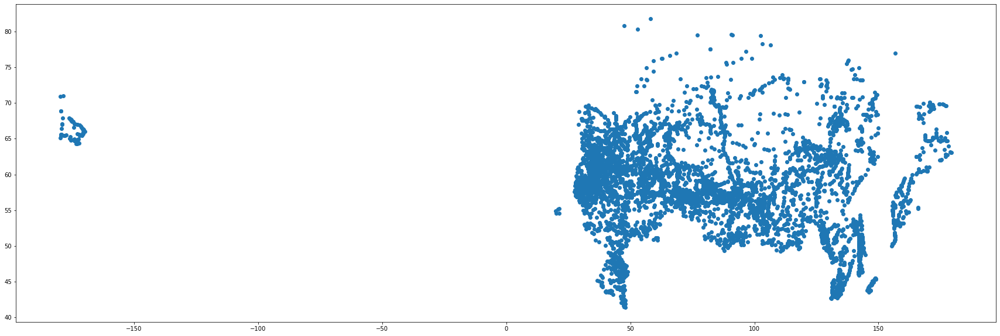

In [ ]:
# Просто показываем точки

plt.figure(figsize= (30,10))
plt.scatter(data['LONG'], data['LAT'])

In [ ]:
from sklearn.metrics import pairwise_distances

class k_means:
    def __init__(self, n_clusters):
        # гиперпараметр - количество кластеров
        self.n_clusters = n_clusters

    def fit(self, X, max_iter=10, visualize=False):
        """
        X - выборка размера количество объектов x количество признаков
        max_iter - максимальное число итераций
        visualize - визуализировать точки ("карту") на каждой итерации
                    (реализуйте поддержку этого флага, только если уже реализовали алгоритм)
        """
        # Цель: обучить центры кластеров self.centers, форма: число кластеров x число признаков

        # Шаг 0: сколько объектов и признаков?
        num_obj = X.shape[0]
        num_feat = X.shape[1]

        # Шаг 1.1: инициализируйте y - вектор длины число объектов,
        # хранящий, к какому кластеру относится каждый объект
        # каждый элемент - случайно выбранный номер кластера (используйте np.random.randint)
        y = np.random.randint(0, self.n_clusters, size=num_obj)

        # Шаг 1.2: создайте матрицу для хранения центров кластеров (используйте np.zeros)
        self.centers = np.zeros((self.n_clusters, num_feat))

        for _ in range(max_iter):
            # Шаг 2: обновите центры кластеров (используйте цикл по номерам кластеров, индексацию, np.mean)
            for c in range(self.n_clusters):
                self.centers[c] = X[y==c].mean(axis=0) # вектор длины num_feat
            # Шаг 3: обновите y. Для этого вычислите расстояния между всеми объектами
            # и центрами кластеров (используйте pairwise_distances),
            # затем найдите ближайший к каждому объекту кластер (используйте np.argmin с указанием axis)
            dists = pairwise_distances(X, self.centers) # число объектов на число окластеров
            # shape (num_obj, self.n_clusters)
            y = np.argmin(dists, axis=1) # вектор длины число объектов

            # (опциональный пункт)
            # Здесь можно реализовать поддержку фрага visualize и отрисовать карту, если visualize=True
            # Отрисовывать точки нужно с помощью plt.scatter, в конце отрисовки графика используйте plt.show()
            if visualize:
                plt.figure(figsize= (30,10))
                plt.scatter(X[:, 1], X[:, 0], c=y)
                plt.show()

    def transform(self, X):
        """
        X - выборка размера количество объектов x количество признаков
        """
        # Цель: вернуть y - номера кластеров, к которым относится каждый объект
        # вектор длины число объектов в X
        dists = pairwise_distances(X, self.centers)
        return np.argmin(dists, axis=1)

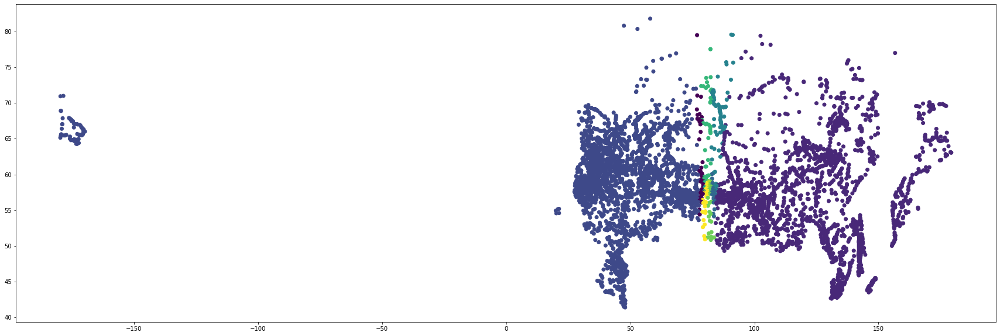

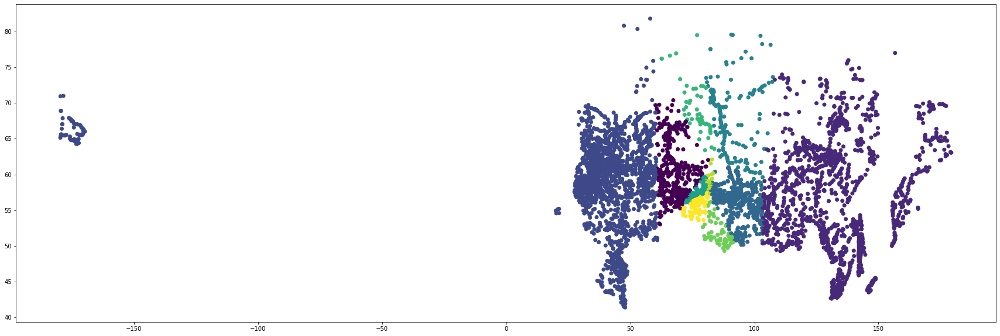

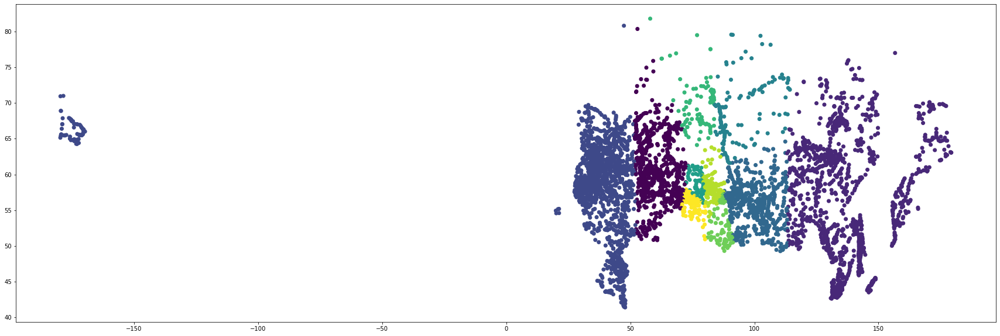

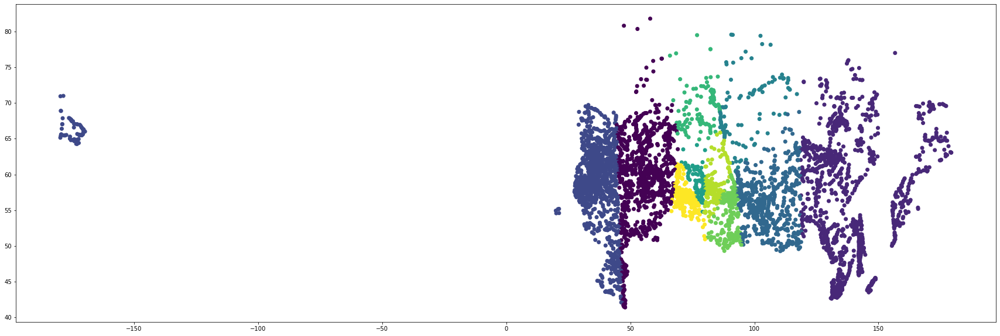

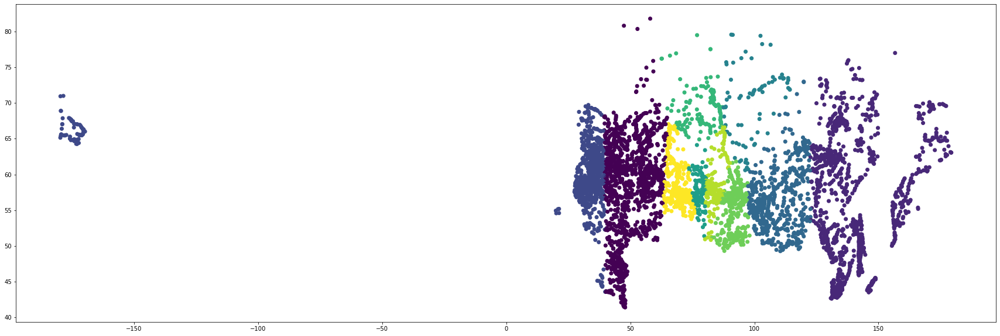

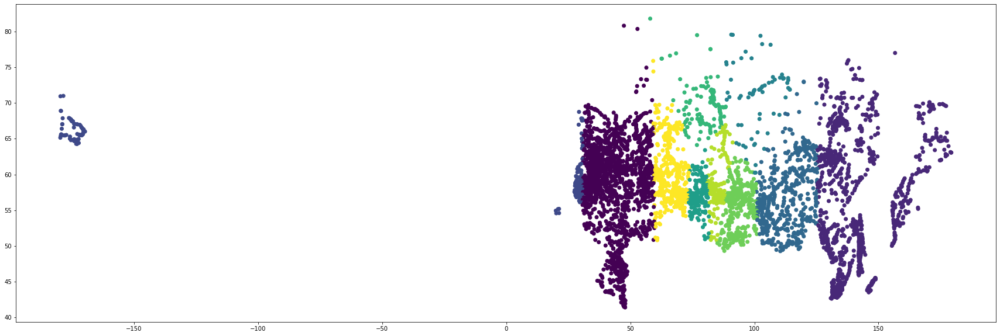

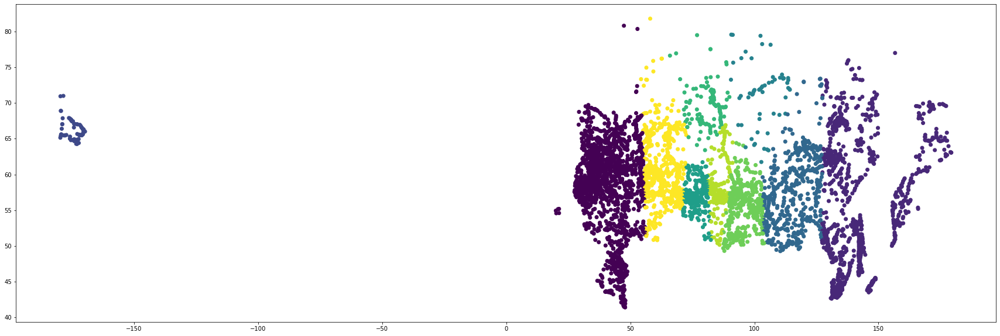

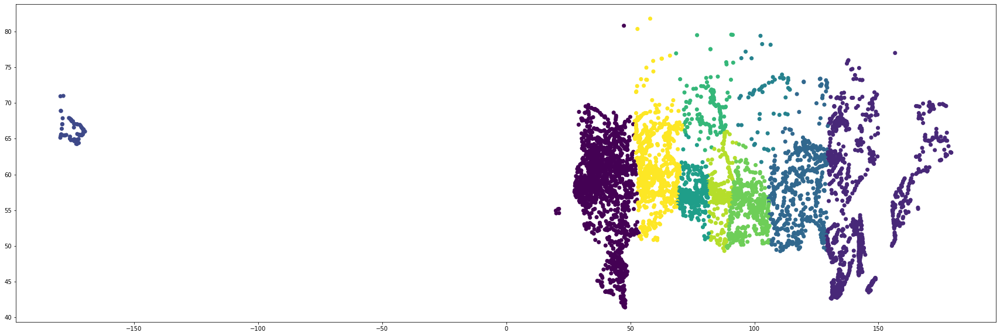

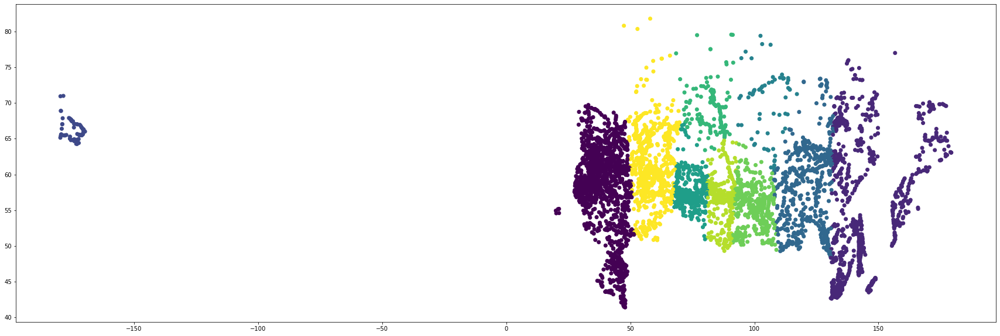

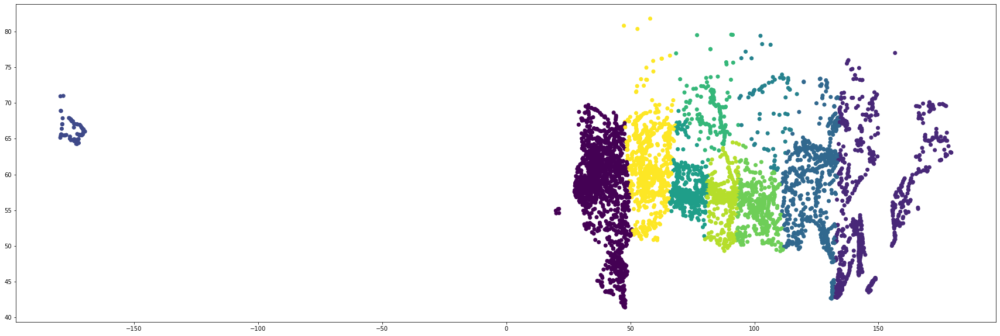

In [ ]:
cls = k_means(10)
cls.fit(data.values, visualize=True) # visualize=True выводит график на каждой итерации
y = cls.transform(data.values)

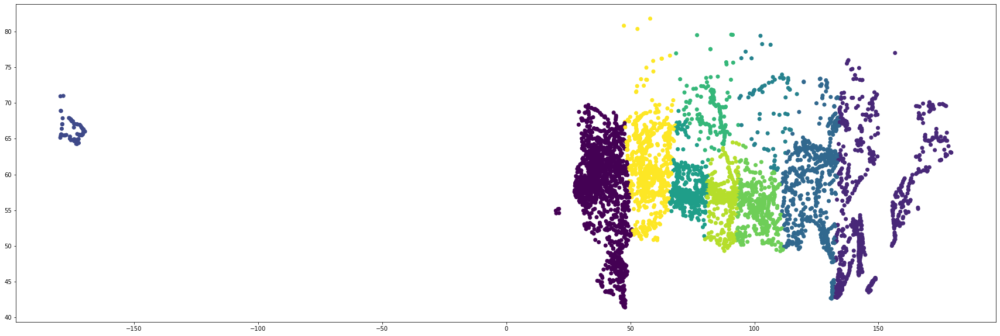

In [ ]:
# Итог

plt.figure(figsize= (30,10))
plt.scatter(data['LONG'], data['LAT'], c=y)

Теперь очередь DBSCAN. Какие ожидания?

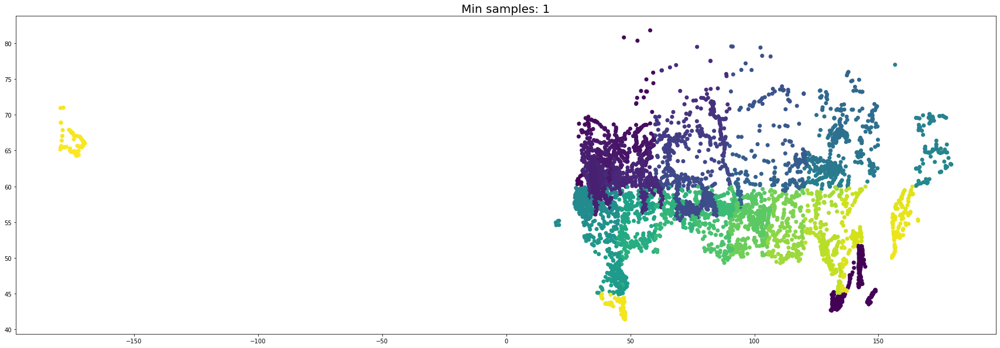

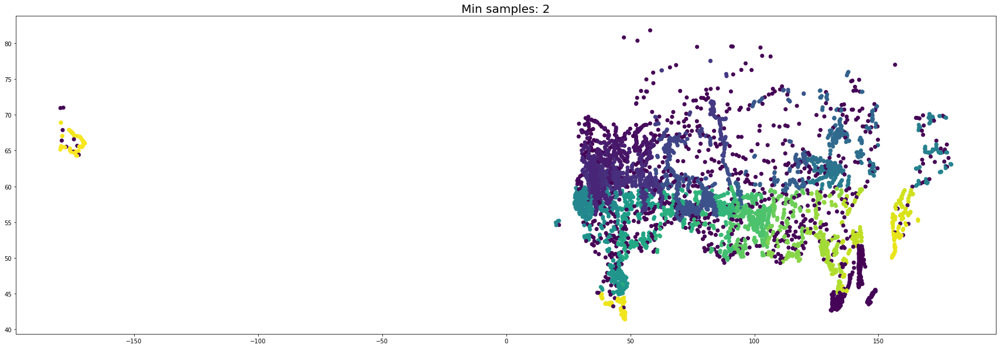

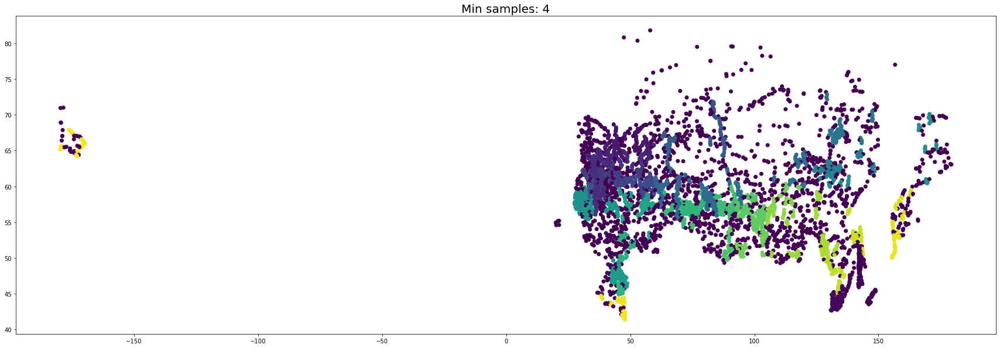

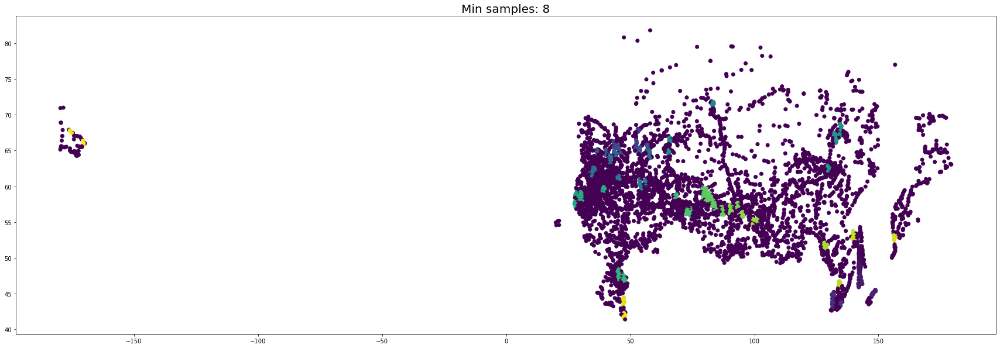

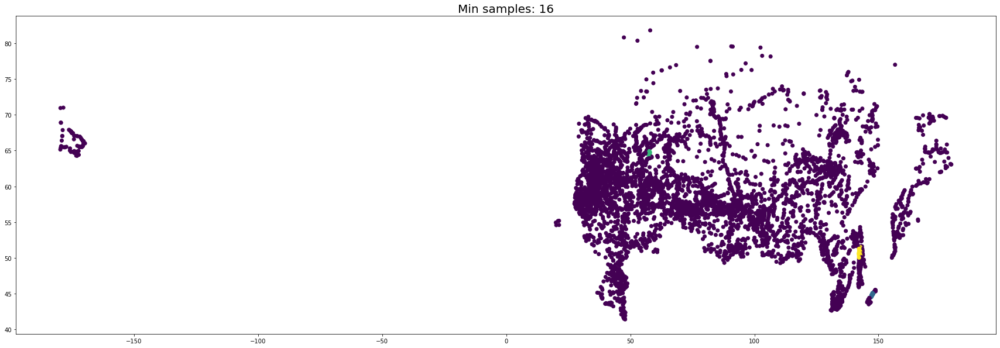

In [ ]:
# Пробуем менять min_samples
from sklearn.cluster import DBSCAN
for k in [1, 2, 4, 8, 16]:
    cls = DBSCAN(min_samples=k)
    y = cls.fit_predict(data.values)
    plt.figure(figsize= (30,10))
    plt.scatter(data['LONG'], data['LAT'], c=y)
    plt.title("Min samples: %d"%k, fontsize=20)
    plt.show()

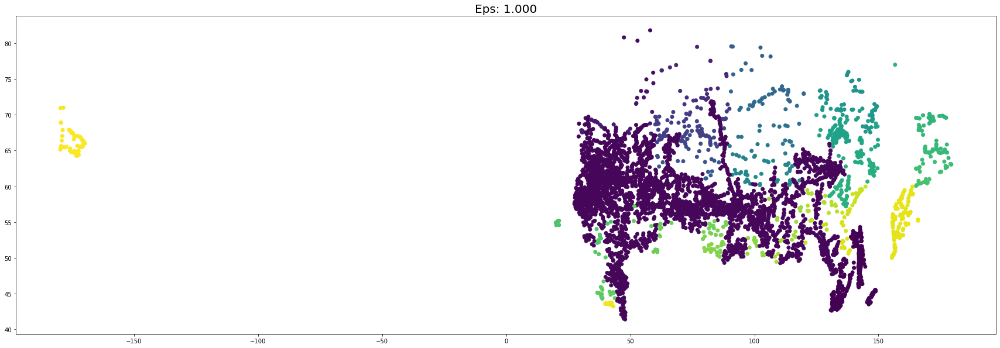

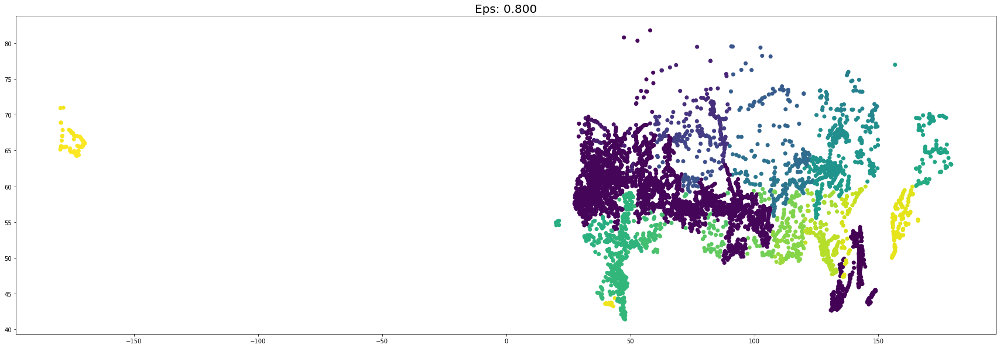

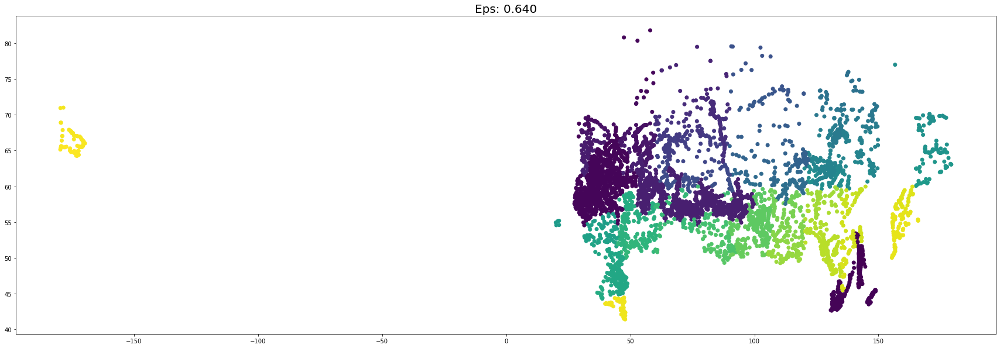

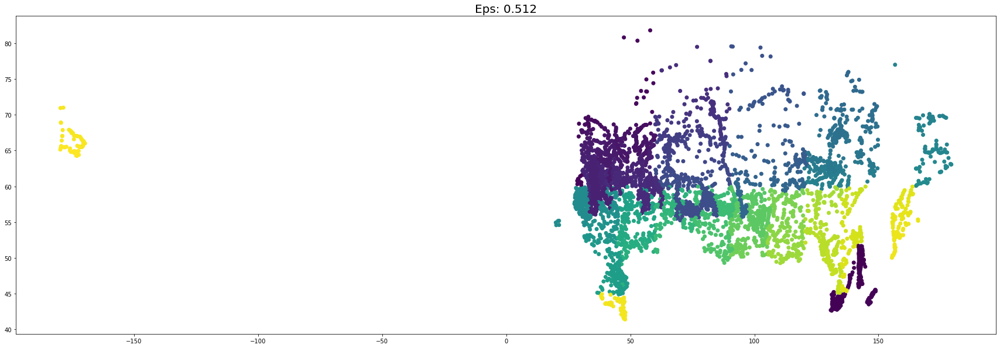

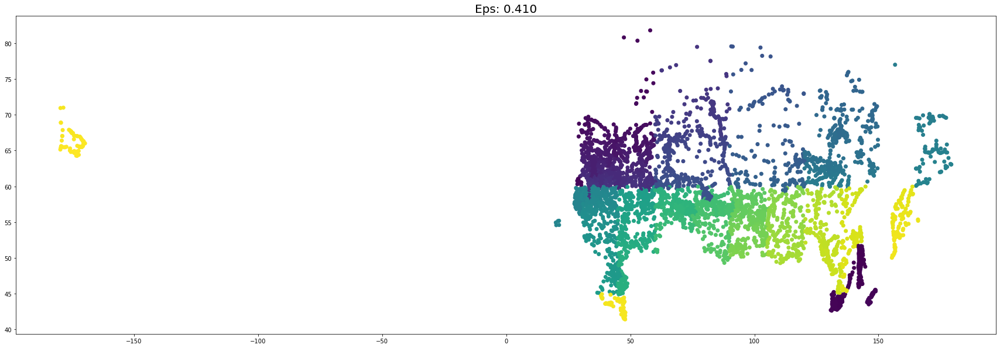

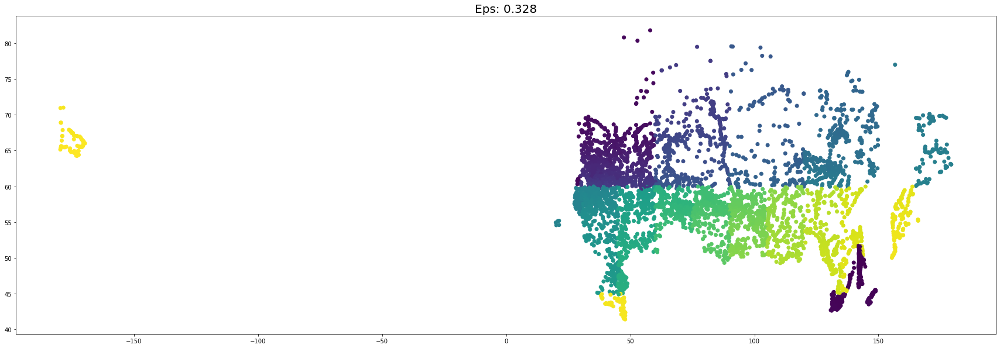

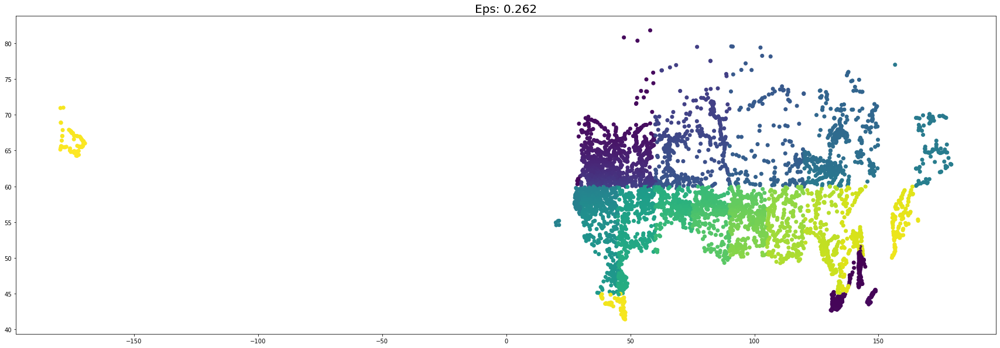

In [ ]:
# Выбрали min_samples = 1
# Пробуем менять eps
from sklearn.cluster import DBSCAN
for eps in 0.8**np.arange(7):
    cls = DBSCAN(min_samples=1, eps=eps)
    y = cls.fit_predict(data.values)
    plt.figure(figsize= (30,10))
    plt.scatter(data['LONG'], data['LAT'], c=y)
    plt.title("Eps: %.3f"%eps, fontsize=20)
    plt.show()

Text(0.5, 1.0, 'Eps: 0')

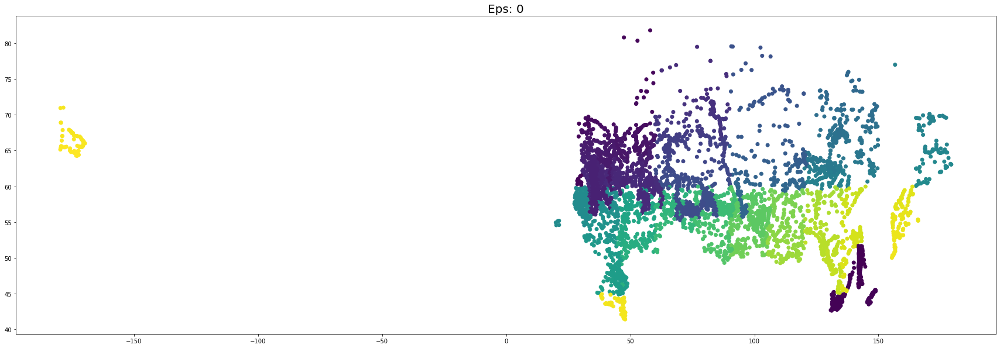

In [ ]:
# Итог

cls = DBSCAN(min_samples=1, eps=0.512)
y = cls.fit_predict(data.values)
plt.figure(figsize= (30,10))
plt.scatter(data['LONG'], data['LAT'], c=y)
plt.title("Eps: %d"%eps, fontsize=20)

Наконец, можно кластеризовать картинки (пиксели)!

Применим наш метод кластеризации к сегментации изображений. Для этого загрузим картинку и будем каждый ее пиксель рассматривать как отдельный объект с тремя признаками R G B, отвечающими за цвет пикселя. Нам понадобится изменить форму тензора с изображением, вытянув все пиксели вдоль одной оси, чтобы получить матрицу объекты-признаки.

(237, 316, 3)


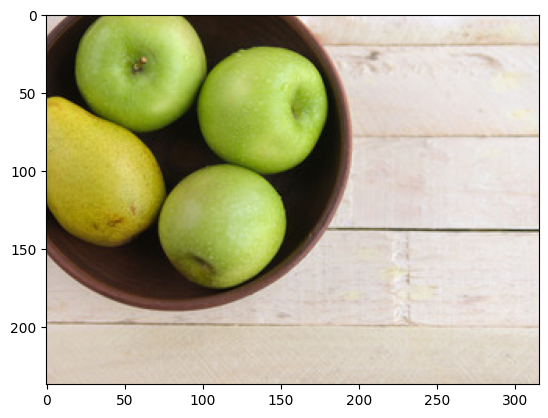

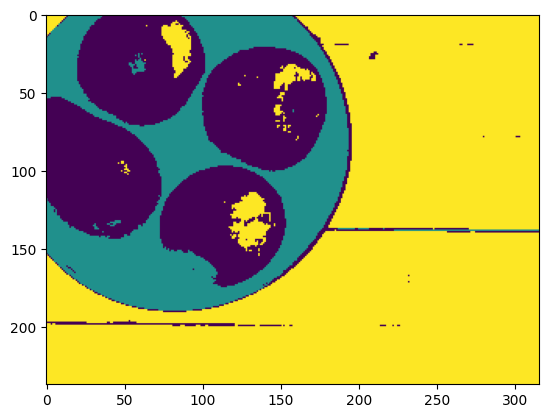

In [14]:
from PIL import Image
import requests
from io import BytesIO
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Загрузка изображения с помощью PIL
url = 'https://raw.githubusercontent.com/iad34/seminars/master/materials/apple.png'
response = requests.get(url)
img = Image.open(BytesIO(response.content))

# Преобразование изображения в массив numpy
img_array = np.array(img)

# Проверка формы изображения
print(img_array.shape)

# Отображение изображения
plt.imshow(img_array)
plt.show()

# Преобразование изображения в двумерный массив (пиксели x RGB)
X = img_array.reshape(-1, 3)

# Кластеризация методом k-means
kmeans = KMeans(n_clusters=3)
kmeans.fit(X)

# Получение меток кластеров для каждого пикселя
y = kmeans.predict(X)

# Преобразование меток обратно в форму изображения
y_reshaped = y.reshape(img_array.shape[:2])

# Отображение результата кластеризации
plt.imshow(y_reshaped, cmap='viridis')
plt.show()

Обратите внимание, что при кластеризации никак не учитывалась информация о положении пикселя на изображении, а учитывался только цвет.

## Оценка качества кластеризации
Оценка качества кластеризации может быть проведена на основе следующих процедур:



*   ручная проверка;
*   установление контрольных точек и проверка на полученных кластерах ;
*   определение стабильности кластеризации путем добавления в модель новых переменных;
*   создание и сравнение кластеров с использованием различных методов. Разные методы кластеризации могут создавать разные кластеры, и это является нормальным явлением. Однако создание схожих кластеров различными методами указывает на правильность кластеризации.









## Еще графики для интерпретации

### Parallel coordinate chart

**Параллельные координаты** являются распространенным способом визуализации и анализа многомерных наборов данных. Чтобы показать набор точек в n-мерном пространстве, рисуется фон, состоящий из n параллельных линий, обычно вертикальных и равномерно распределенных

C:\Users\User\AppData\Local\Temp\ipykernel_19472\3326211948.py:49: UserWarning:

FixedFormatter should only be used together with FixedLocator

C:\Users\User\AppData\Local\Temp\ipykernel_19472\3326211948.py:60: UserWarning:

FixedFormatter should only be used together with FixedLocator



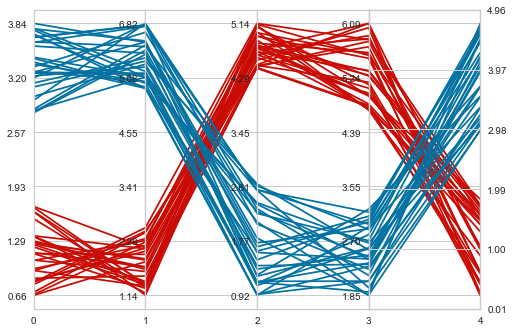

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def parallel_coordinates(data_sets, style=None):

    dims = len(data_sets[0])
    x    = range(dims)
    fig, axes = plt.subplots(1, dims-1, sharey=False)

    if style is None:
        style = ['r-']*len(data_sets)

    # Calculate the limits on the data
    min_max_range = list()
    for m in zip(*data_sets):
        mn = min(m)
        mx = max(m)
        if mn == mx:
            mn -= 0.5
            mx = mn + 1.
        r  = float(mx - mn)
        min_max_range.append((mn, mx, r))

    # Normalize the data sets
    norm_data_sets = list()
    for ds in data_sets:
        nds = [(value - min_max_range[dimension][0]) /
                min_max_range[dimension][2]
                for dimension,value in enumerate(ds)]
        norm_data_sets.append(nds)
    data_sets = norm_data_sets

    # Plot the datasets on all the subplots
    for i, ax in enumerate(axes):
        for dsi, d in enumerate(data_sets):
            ax.plot(x, d, style[dsi])
        ax.set_xlim([x[i], x[i+1]])

    # Set the x axis ticks
    for dimension, (axx,xx) in enumerate(zip(axes, x[:-1])):
        axx.xaxis.set_major_locator(ticker.FixedLocator([xx]))
        ticks = len(axx.get_yticklabels())
        labels = list()
        step = min_max_range[dimension][2] / (ticks - 1)
        mn   = min_max_range[dimension][0]
        for i in range(ticks):
            v = mn + i*step
            labels.append('%4.2f' % v)
        axx.set_yticklabels(labels)


    # Move the final axis' ticks to the right-hand side
    axx = plt.twinx(axes[-1])
    dimension += 1
    axx.xaxis.set_major_locator(ticker.FixedLocator([x[-2], x[-1]]))
    ticks = len(axx.get_yticklabels())
    step = min_max_range[dimension][2] / (ticks - 1)
    mn   = min_max_range[dimension][0]
    labels = ['%4.2f' % (mn + i*step) for i in range(ticks)]
    axx.set_yticklabels(labels)

    # Stack the subplots
    plt.subplots_adjust(wspace=0)

    return plt


if __name__ == '__main__':
    import random
    base  = [0,   0,  5,   5,  0]
    scale = [1.5, 2., 1.0, 2., 2.]
    data = [[base[x] + random.uniform(0., 1.)*scale[x]
            for x in range(5)] for y in range(30)]
    colors = ['r'] * 30

    base  = [3,   6,  0,   1,  3]
    scale = [1.5, 2., 2.5, 2., 2.]
    data.extend([[base[x] + random.uniform(0., 1.)*scale[x]
                 for x in range(5)] for y in range(30)])
    colors.extend(['b'] * 30)

    parallel_coordinates(data, style=colors).show()

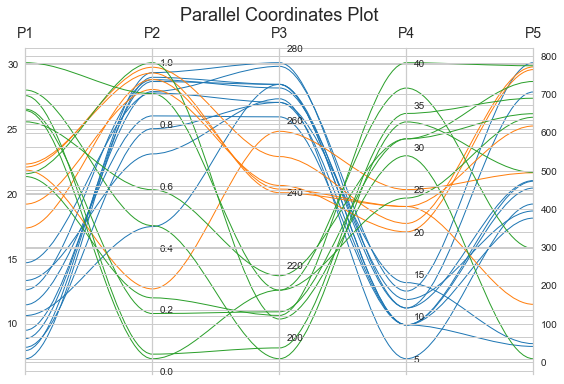

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.path import Path
import matplotlib.patches as patches
import numpy as np

fig, host = plt.subplots()

# create some dummy data
ynames = ['P1', 'P2', 'P3', 'P4', 'P5']
N1, N2, N3 = 10, 5, 8
N = N1 + N2 + N3
category = np.concatenate([np.full(N1, 1), np.full(N2, 2), np.full(N3, 3)])
y1 = np.random.uniform(0, 10, N) + 7 * category
y2 = np.sin(np.random.uniform(0, np.pi, N)) ** category
y3 = np.random.binomial(300, 1 - category / 10, N)
y4 = np.random.binomial(200, (category / 6) ** 1/3, N)
y5 = np.random.uniform(0, 800, N)

# organize the data
ys = np.dstack([y1, y2, y3, y4, y5])[0]
ymins = ys.min(axis=0)
ymaxs = ys.max(axis=0)
dys = ymaxs - ymins
ymins -= dys * 0.05  # add 5% padding below and above
ymaxs += dys * 0.05
dys = ymaxs - ymins

# transform all data to be compatible with the main axis
zs = np.zeros_like(ys)
zs[:, 0] = ys[:, 0]
zs[:, 1:] = (ys[:, 1:] - ymins[1:]) / dys[1:] * dys[0] + ymins[0]


axes = [host] + [host.twinx() for i in range(ys.shape[1] - 1)]
for i, ax in enumerate(axes):
    ax.set_ylim(ymins[i], ymaxs[i])
    ax.spines['top'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    if ax != host:
        ax.spines['left'].set_visible(False)
        ax.yaxis.set_ticks_position('right')
        ax.spines["right"].set_position(("axes", i / (ys.shape[1] - 1)))

host.set_xlim(0, ys.shape[1] - 1)
host.set_xticks(range(ys.shape[1]))
host.set_xticklabels(ynames, fontsize=14)
host.tick_params(axis='x', which='major', pad=7)
host.spines['right'].set_visible(False)
host.xaxis.tick_top()
host.set_title('Parallel Coordinates Plot', fontsize=18)

colors = plt.cm.tab10.colors
for j in range(N):
    # to just draw straight lines between the axes:
    # host.plot(range(ys.shape[1]), zs[j,:], c=colors[(category[j] - 1) % len(colors) ])

    # create bezier curves
    # for each axis, there will a control vertex at the point itself, one at 1/3rd towards the previous and one
    #   at one third towards the next axis; the first and last axis have one less control vertex
    # x-coordinate of the control vertices: at each integer (for the axes) and two inbetween
    # y-coordinate: repeat every point three times, except the first and last only twice
    verts = list(zip([x for x in np.linspace(0, len(ys) - 1, len(ys) * 3 - 2, endpoint=True)],
                     np.repeat(zs[j, :], 3)[1:-1]))
    # for x,y in verts: host.plot(x, y, 'go') # to show the control points of the beziers
    codes = [Path.MOVETO] + [Path.CURVE4 for _ in range(len(verts) - 1)]
    path = Path(verts, codes)
    patch = patches.PathPatch(path, facecolor='none', lw=1, edgecolor=colors[category[j] - 1])
    host.add_patch(patch)
plt.tight_layout()
plt.show()

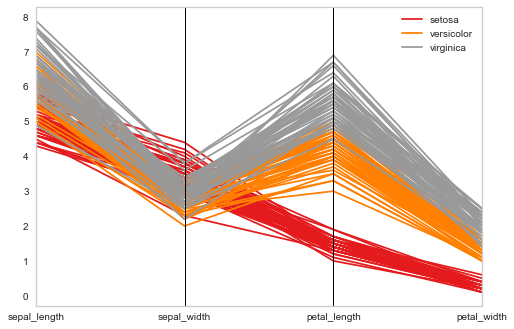

In [ ]:
# libraries
import pandas
import matplotlib.pyplot as plt
from pandas.plotting import parallel_coordinates

# Take the iris dataset
import seaborn as sns
data = sns.load_dataset('iris')

# Make the plot
parallel_coordinates(data, 'species', colormap=plt.get_cmap("Set1"))
plt.show()

In [ ]:
# Import the library
import plotly.express as px

# Load the iris dataset provided by the library
df = px.data.iris()
# Create the chart:
fig = px.parallel_coordinates(
    df,
    color="species_id",
    labels={"species_id": "Species","sepal_width": "Sepal Width", "sepal_length": "Sepal Length", "petal_width": "Petal Width", "petal_length": "Petal Length", },
    color_continuous_scale=px.colors.diverging.Tealrose,
    color_continuous_midpoint=2)

# Hide the color scale that is useless in this case
fig.update_layout(coloraxis_showscale=False)

# Show the plot
fig.show()